# SPAD ODMR Batch Analysis — Notebook README

> **Goal**: Load one or more pre-processed ODMR datasets (`.npz` exports from `SPAD_ODMR_spc3read.ipynb` / `batch_odmr_hermesread.py`), compute weighted-average contrast curves, fit Lorentzians per pixel and for an integrated ROI, and produce diagnostic plots.

---
## Prerequisites
All input files must already be generated by `SPAD_ODMR_spc3read.ipynb` or `batch_odmr_hermesread.py`. This notebook does **not** load raw `.spc3`/`.hrm` files or perform background subtraction — that is handled upstream.

---
## Configuration (Cells 2 & 4)

Set `FIT_MODE` in Cell 2 to select single or double Lorentzian fitting (e.g. double when the dip is split by an axial B-field):

```python
FIT_MODE = 'single'  # 'single' or 'double'
```

Set `spad_processed_subdir` in Cell 4 to the name of the sub-directory (under `spad_processed_dir`, i.e. `<spad_dir>/processed/`) that holds the `.npz` files for the run you want to analyze:

```python
spad_processed_subdir = '463_pulsed_odmr_gradient_tracking_194657_20260714-191740'
```

This directory is created automatically by `batch_odmr_hermesread.py` (named `<dataset_tag>_<run_timestamp>`, printed by that script as it runs). The loader cell (Cell 5) globs **every** `.npz` file in that directory and loads them all — their contrasts are weighted-averaged by `n_complete_reps` before fitting. No more manually listing individual filenames.

---
## Memory variables after loading (Cell 5)
| Variable | Shape | Description |
|---|---|---|
| `spad_processed_files` | list of str | `.npz` filenames discovered in `spad_processed_subdir`, sorted |
| `sig_avg_cps_bgsub_all` | `(N_files, F, rows, cols)` | Background-subtracted signal, counts/s/pixel |
| `ref_avg_cps_bgsub_all` | `(N_files, F, rows, cols)` | Background-subtracted reference, counts/s/pixel |
| `n_complete_reps_all` | list of int | Repetition counts per file (used as weights) |
| `f_vec` | `(F,)` | MW IF frequency axis (Hz) |
| `bright_rc` | `(row, col)` | Brightest pixel in the mean reference frame |

---
## Analysis cells (in order)
1. **Reference frame image** — plots mean reference frame and locates `bright_rc` (brightest pixel), used as the array centre for all subsequent per-pixel indexing.
2. **Total counts + contrast** — sums all pixels and plots raw signal/reference counts and the aggregate contrast curve per file.
3. **3×3 raw traces** — plots signal and reference cps for a 3×3 sparse grid (`bright_rc ± (0, 2)`) without fitting.
4. **Weighted-average contrast (all pixels)** — computes weighted average across files and plots the full-array contrast curve.
5. **3×3 Lorentzian fits** — fits a single or double Lorentzian dip (controlled by `FIT_MODE`) to each pixel in the 3×3 grid; overlays fit curve; prints `f0`/`f01`+`f02`, `FWHM`, amplitude per pixel.
6. **5×5 ROI integrated contrast** — sums signal/reference over a 5×5 pixel crop centred on `bright_rc`, fits Lorentzian (single or double), reports SNR from residual RMS.
7. **5×5 ROI with reference noise SNR** — same ROI but computes SNR from the standard deviation of the reference measurement.

---
## Notes
- `bright_rc` is recomputed per file in some cells and used from the last file's value in others — rerun from Cell 5 if you change `spad_processed_subdir`.
- All pixel indexing uses the sparse step of ±2 (not ±1) for the 3×3 grid to match the NV array pitch.

In [34]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from types import SimpleNamespace
from pathlib import Path
import re
from importlib import reload
from spc import SPC3
def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'experiment-main').exists():
            return p
    raise RuntimeError('Could not find workspace root containing experiment-main')

WORKSPACE = find_workspace_root(Path.cwd())
sys.path.insert(0, str(WORKSPACE / 'experiment-main'))
from qua_tools_nv2.dataset import DatasetReader
from qua_tools_nv2.nv2_fits import Fitter



In [ ]:
spad_processed_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\processed'
qm_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD'

# Fit mode: 'single' for one Lorentzian dip, 'double' for two (e.g. split by axial B-field)
FIT_MODE = 'double'  # 'single' or 'double'

In [ ]:
# Sub-directory inside spad_processed_dir containing this run's .npz files.
# Created automatically by batch_odmr_hermesread.py as '<dataset_tag>_<run_timestamp>'
# (printed by that script as "Output directory : ..." when it runs).
spad_processed_subdir = '463_pulsed_odmr_gradient_tracking_194657_20260714-191740'


In [ ]:
processed_loaded = False
spc3_file_0 = None
qm_file_from_processed = None
processed_metadata_export = None

def _load_processed_header_txt(header_path: Path) -> dict:
    """Parse the *_header.txt created by the export cell and return the JSON dict."""
    text = header_path.read_text(encoding='utf-8')
    json_start = text.find('{')
    if json_start < 0:
        raise ValueError(f"No JSON object found in header file: {header_path}")
    return json.loads(text[json_start:])


processed_dir = Path(spad_processed_dir) / spad_processed_subdir
if not processed_dir.is_dir():
    raise FileNotFoundError(f"Processed sub-directory not found: {processed_dir}")

spad_processed_files = sorted(p.name for p in processed_dir.glob('*.npz'))
if not spad_processed_files:
    raise FileNotFoundError(f"No .npz files found in: {processed_dir}")

print(f"Found {len(spad_processed_files)} processed file(s) in {processed_dir}:")
for f in spad_processed_files:
    print(f"  {f}")
print()

sig_avg_cps_bgsub_all = []
ref_avg_cps_bgsub_all = []
n_complete_reps_all = []

for spad_processed_file in spad_processed_files:
    processed_path = processed_dir / spad_processed_file

    print(f"Loading processed arrays from: {processed_path}")

    with np.load(processed_path, allow_pickle=True) as npz:
        sig_avg_cps_bgsub = np.asarray(npz['sig_avg_cps_bgsub'])
        ref_avg_cps_bgsub = np.asarray(npz['ref_avg_cps_bgsub'])
        f_vec = np.asarray(npz['f_vec'])
        n_complete_reps = int(np.asarray(npz['n_complete_reps']).item())

    processed_loaded = True

    print(
        "Loaded processed arrays:\n"
        f"  sig_avg_cps_bgsub: {sig_avg_cps_bgsub.shape}\n"
        f"  ref_avg_cps_bgsub: {ref_avg_cps_bgsub.shape}\n"
        f"  f_vec           : {f_vec.shape}\n"
        f"  n_complete_reps : {n_complete_reps}\n"
    )

    # Load companion header file and extract references
    processed_header_path = processed_path.parent / f"{processed_path.stem}_header.txt"
    if processed_header_path.exists():
        processed_metadata_export = _load_processed_header_txt(processed_header_path)
        spc3_file_0 = (
            processed_metadata_export.get('spc3_data', {}).get('spc3 file 0')
            if isinstance(processed_metadata_export, dict)
            else None
        )
        qm_file_from_processed = (
            processed_metadata_export.get('run_info', {}).get('qm_file')
            if isinstance(processed_metadata_export, dict)
            else None
        )

        #print(
        #    "Loaded processed header references:\n"
        #    f"  spc3 file 0: {spc3_file_0}\n"
        #    f"  qm file    : {qm_file_from_processed}"
        #)
    sig_avg_cps_bgsub_all.append(sig_avg_cps_bgsub)
    ref_avg_cps_bgsub_all.append(ref_avg_cps_bgsub)
    n_complete_reps_all.append(n_complete_reps)


n_total = np.sum(n_complete_reps_all)
print(f"Total number of complete repetitions across all processed files: {n_total}")

sig_avg_cps_bgsub_all = np.array(sig_avg_cps_bgsub_all)
ref_avg_cps_bgsub_all = np.array(ref_avg_cps_bgsub_all)

#sig_avg = np.average(sig_avg_cps_bgsub_all, axis=0, weights=n_complete_reps_all)
#ef_avg = np.average(ref_avg_cps_bgsub_all, axis=0, weights=n_complete_reps_all)



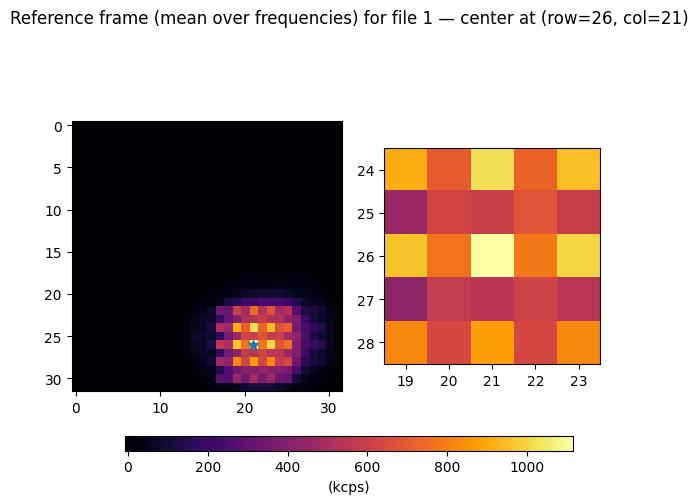

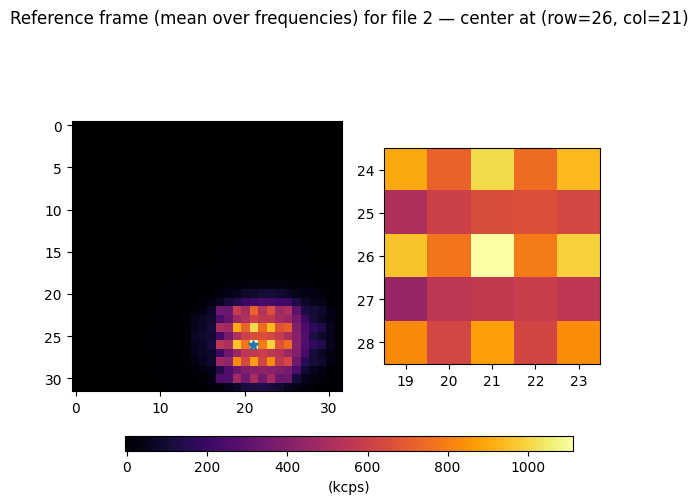

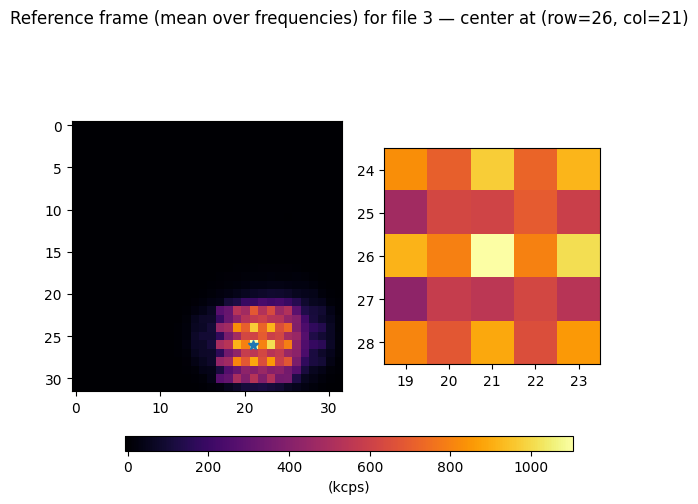

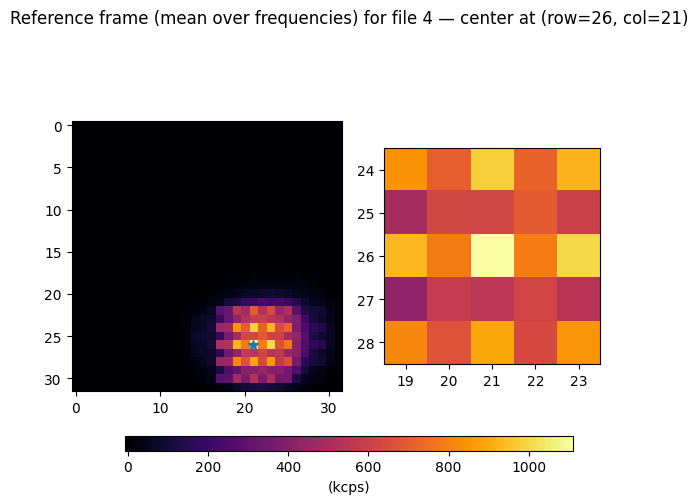

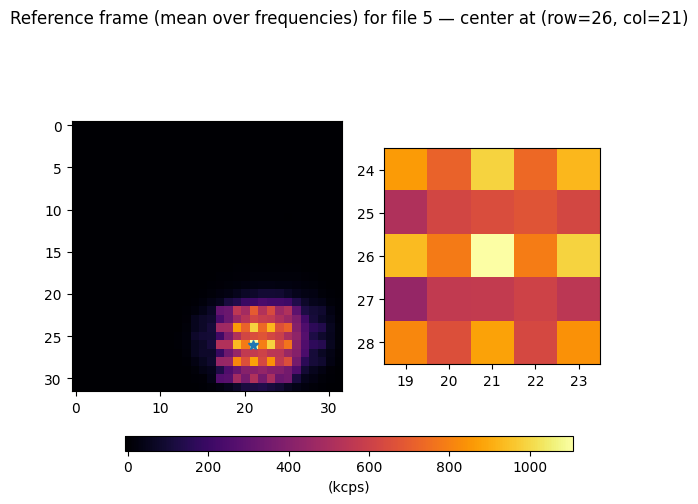

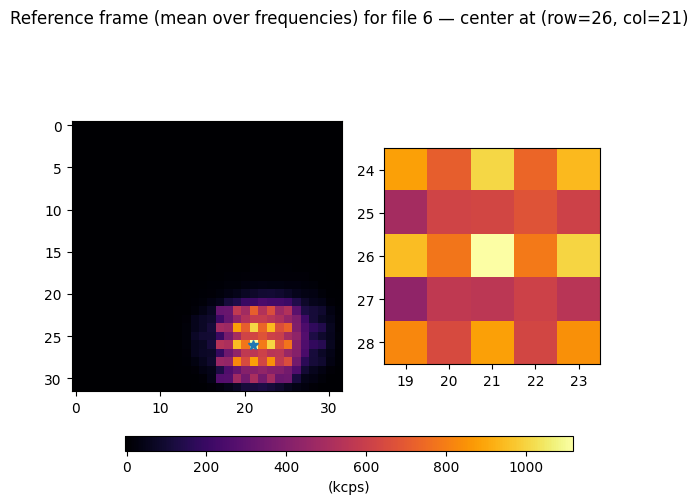

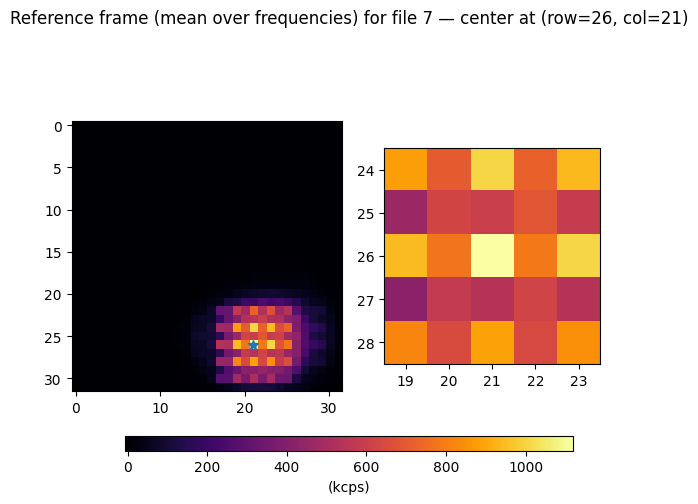

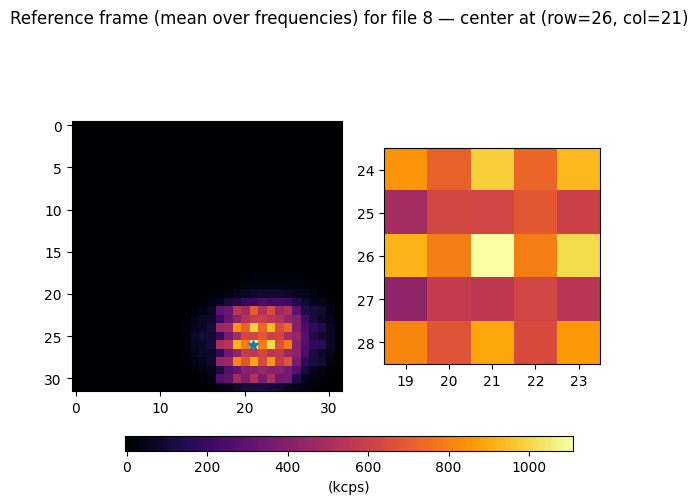

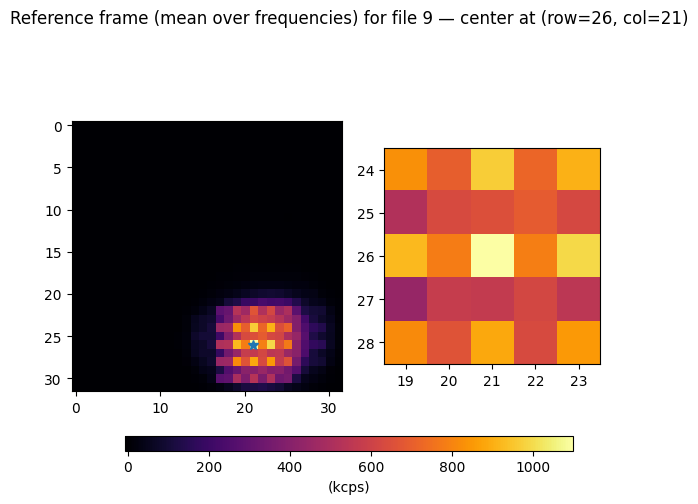

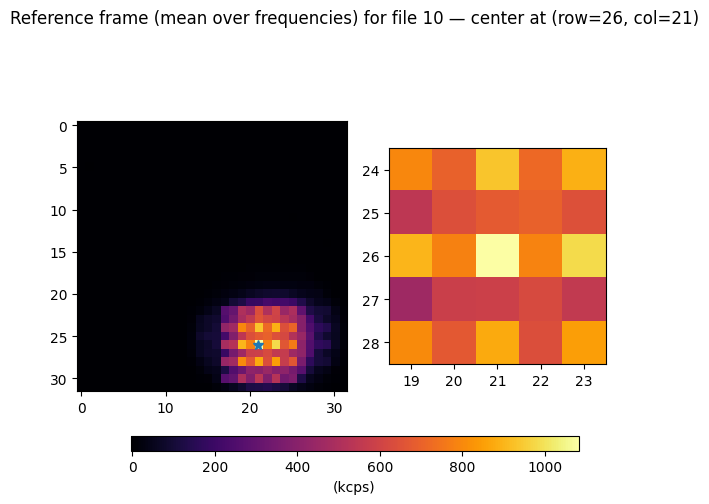

File 1 array centre (brightest pixel in ref_avg.mean): row=26, col=21
File 1 count at array centre: 1115613.298353264
File 2 array centre (brightest pixel in ref_avg.mean): row=26, col=21
File 2 count at array centre: 1113358.182731921
File 3 array centre (brightest pixel in ref_avg.mean): row=26, col=21
File 3 count at array centre: 1104701.187640153
File 4 array centre (brightest pixel in ref_avg.mean): row=26, col=21
File 4 count at array centre: 1110738.3552700437
File 5 array centre (brightest pixel in ref_avg.mean): row=26, col=21
File 5 count at array centre: 1107845.816151632
File 6 array centre (brightest pixel in ref_avg.mean): row=26, col=21
File 6 count at array centre: 1119733.3954823469
File 7 array centre (brightest pixel in ref_avg.mean): row=26, col=21
File 7 count at array centre: 1119719.6176770136
File 8 array centre (brightest pixel in ref_avg.mean): row=26, col=21
File 8 count at array centre: 1110253.554300442
File 9 array centre (brightest pixel in ref_avg.mean)

In [38]:
# Use the mean reference frame (averaged over all frequencies) to find the array centre.
n = 5  # size of ROI (n x n pixels)

for k in range(len(n_complete_reps_all)):

    ref_frame = ref_avg_cps_bgsub_all[k,:,:].mean(axis =0)  # (rows, cols) — mean reference over all frequencies
    bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
    #print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')
    
    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(1e-3*ref_frame, cmap='inferno')
    plt.plot(bright_rc[1], bright_rc[0], '*', ms=7)

    plt.subplot(1, 2, 2)
    plt.imshow(1e-3*ref_frame, cmap='inferno')
    plt.xlim(bright_rc[1]-int(n/2)-0.5, bright_rc[1]+int(n/2)+0.5)
    plt.ylim(bright_rc[0]+int(n/2)+0.5, bright_rc[0]-int(n/2)-0.5)
    plt.colorbar(label='(kcps)')
    # Replace the per-subplot colorbar with a single shared colorbar (horizontal, bottom)
    fig = plt.gcf()

    # First two axes are the image subplots; any additional axes are the colorbar axes we just created
    ax1, ax2 = fig.axes[0], fig.axes[1]
    for ax_extra in list(fig.axes[2:]):
        ax_extra.remove()

    im1 = ax1.images[-1]
    im2 = ax2.images[-1]
    im2.set_norm(im1.norm)  # ensure both subplots share the same normalization

    # Add a dedicated colorbar axes at the bottom; exclude from tight_layout calculations
    cax = fig.add_axes([0.15, 0.06, 0.70, 0.03])
    cax.set_in_layout(False)

    cbar = fig.colorbar(im1, cax=cax, orientation="horizontal")
    cbar.set_label("(kcps)")
    plt.suptitle(f'Reference frame (mean over frequencies) for file {k+1} — center at (row={bright_rc[0]}, col={bright_rc[1]})')
    plt.tight_layout()

plt.show()
#print counts at bright rc for each file
for k in range(len(n_complete_reps_all)):
    
    ref_frame = ref_avg_cps_bgsub_all[k,:,:].mean(axis =0)  # (rows, cols) — mean reference over all frequencies
    bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
    print(f'File {k+1} array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')
    print(f'File {k+1} count at array centre: {ref_frame[bright_rc]}')

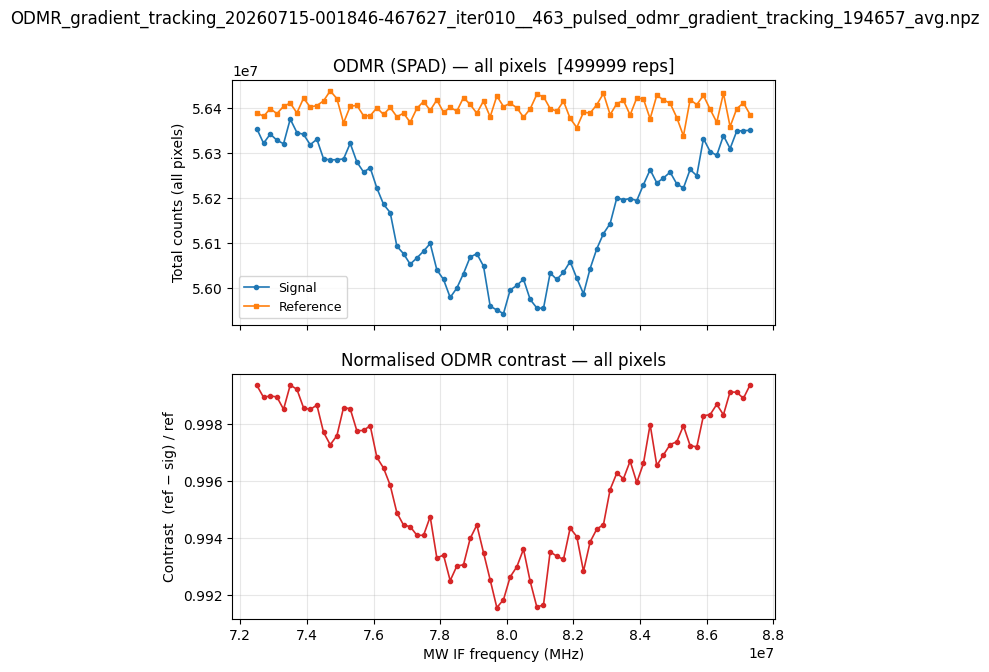

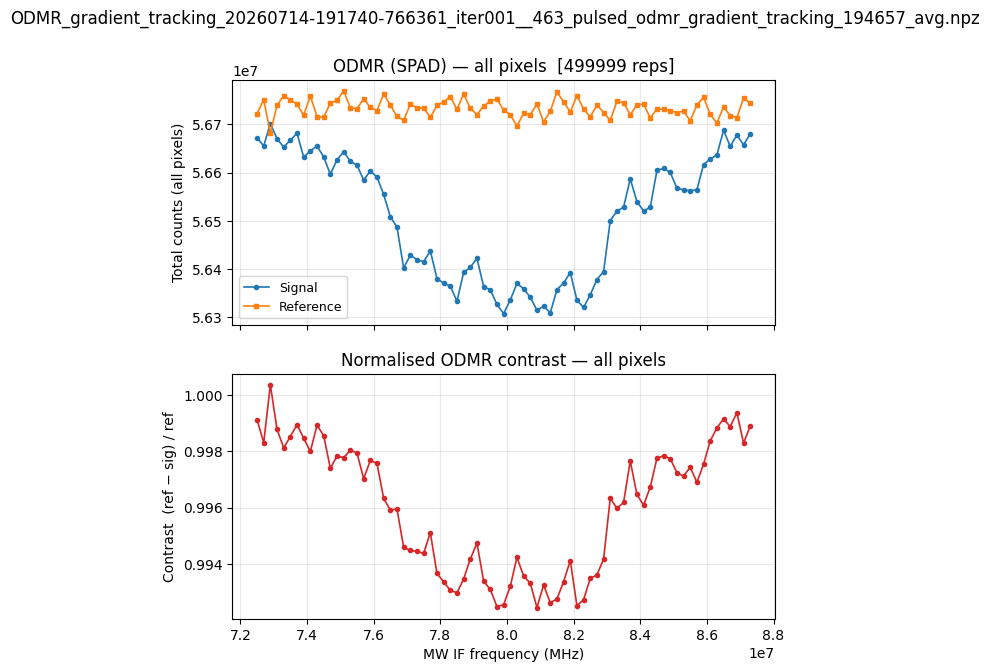

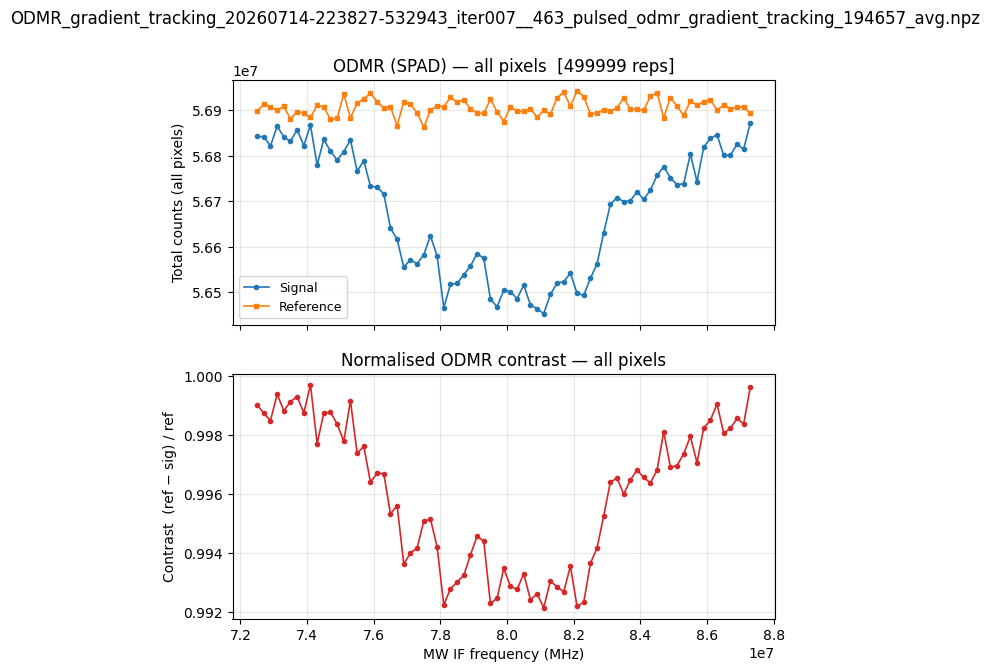

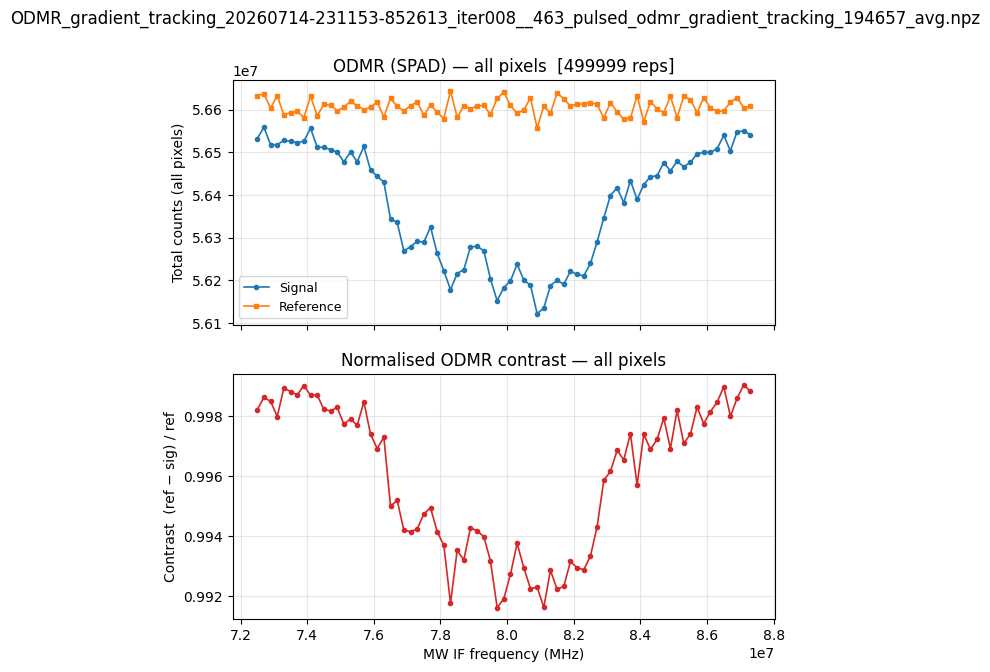

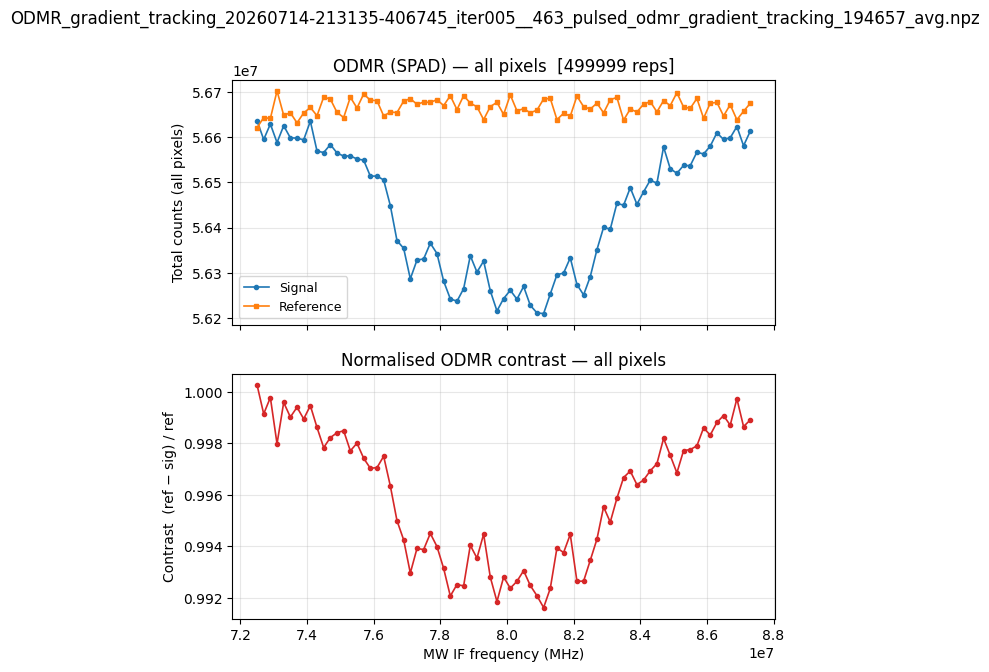

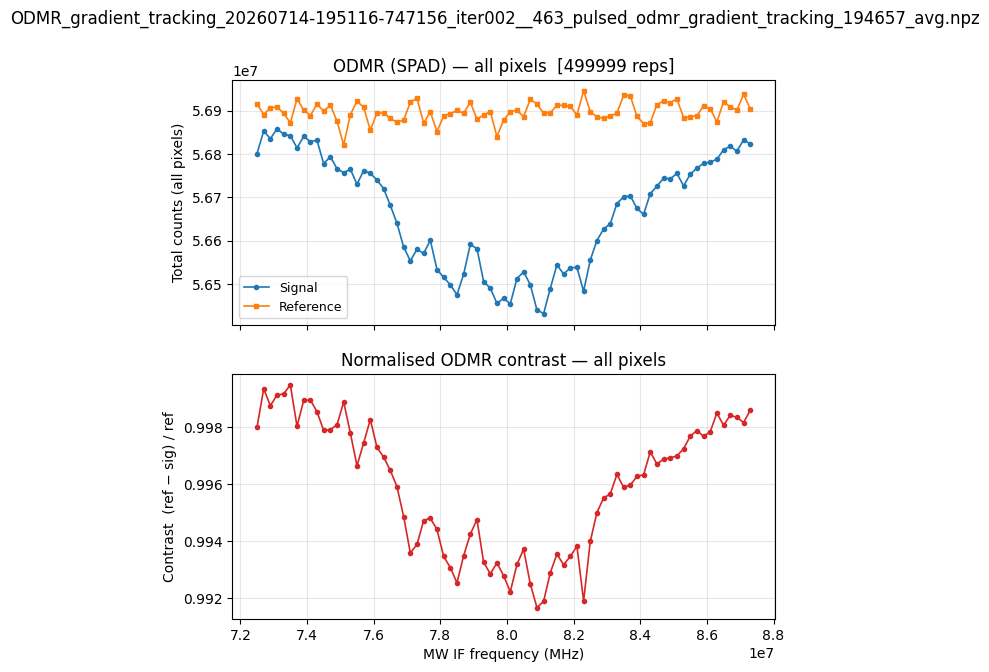

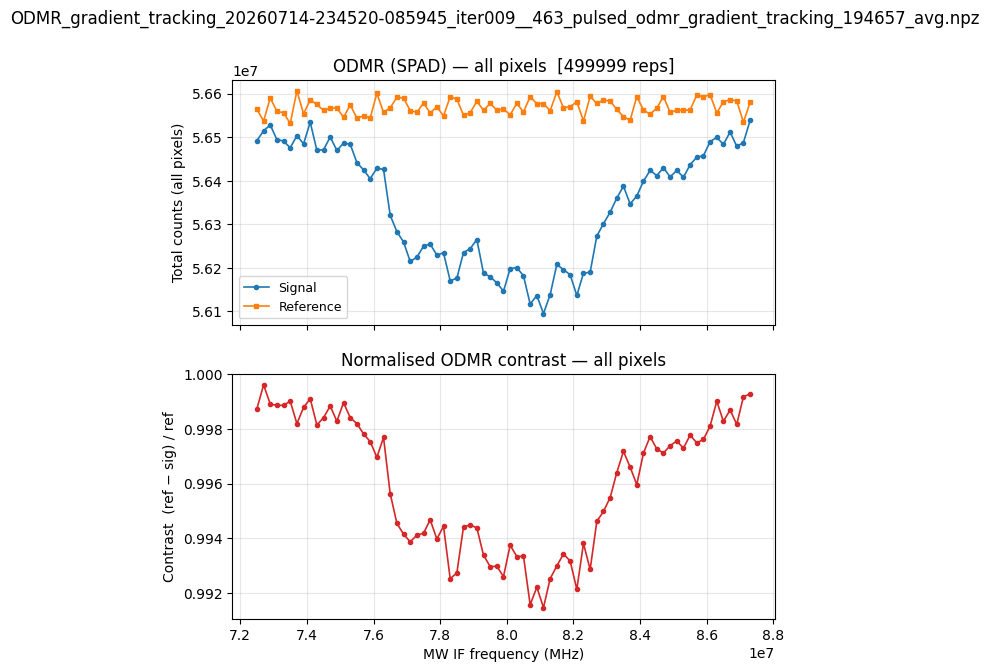

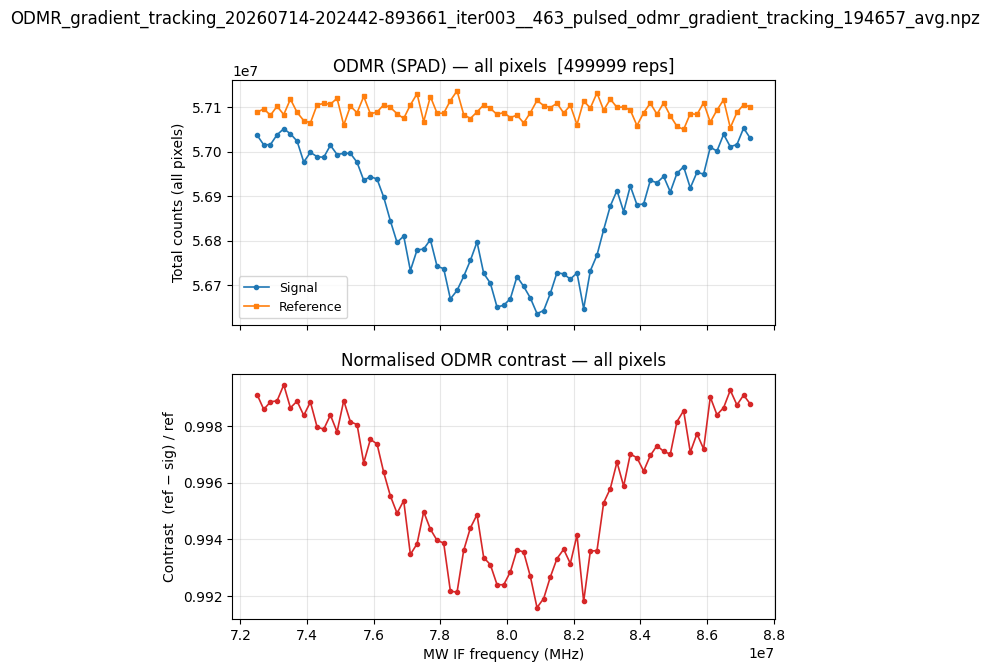

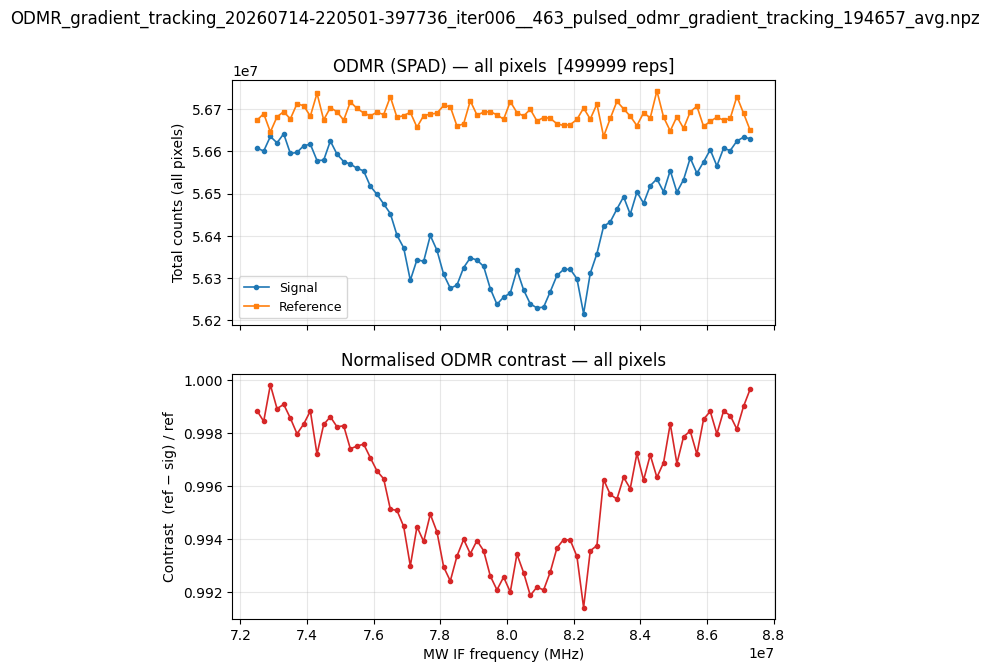

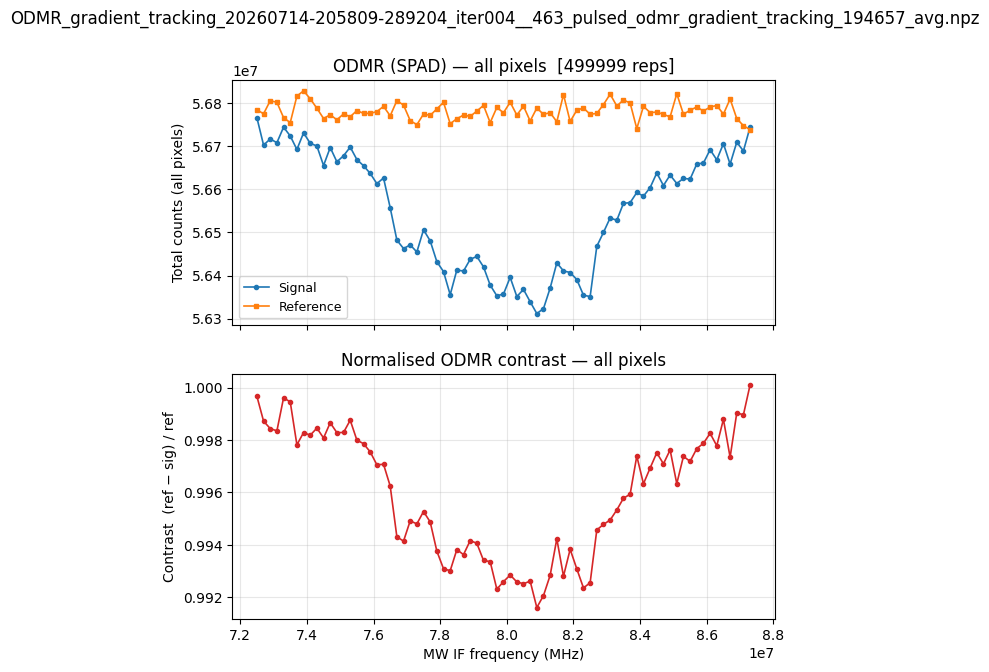

In [39]:
for k in range(len(spad_processed_files)):
    sig_counts  = sig_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)
    ref_counts  = ref_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)

    with np.errstate(divide='ignore', invalid='ignore'):
        contrast_all = np.where(ref_counts != 0, 1 - (ref_counts - sig_counts) / ref_counts, 0.0)

    fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
    
    plt.suptitle(f'{list(spad_processed_files)[k]}')
    axes[0].plot(f_vec, sig_counts, 'o-', ms=3, lw=1.2, label='Signal')
    axes[0].plot(f_vec, ref_counts, 's-', ms=3, lw=1.2, label='Reference')
    axes[0].set_ylabel('Total counts (all pixels)')
    axes[0].set_title(f'ODMR (SPAD) — all pixels  [{n_complete_reps_all[k]} reps]')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(f_vec, contrast_all, 'o-', ms=3, lw=1.2, color='C3')
    axes[1].set_xlabel('MW IF frequency (MHz)')
    axes[1].set_ylabel('Contrast  (ref − sig) / ref')
    axes[1].set_title('Normalised ODMR contrast — all pixels')
    axes[1].grid(True, alpha=0.3)
    #axes[1].set_ylim([0.96, 1.01])

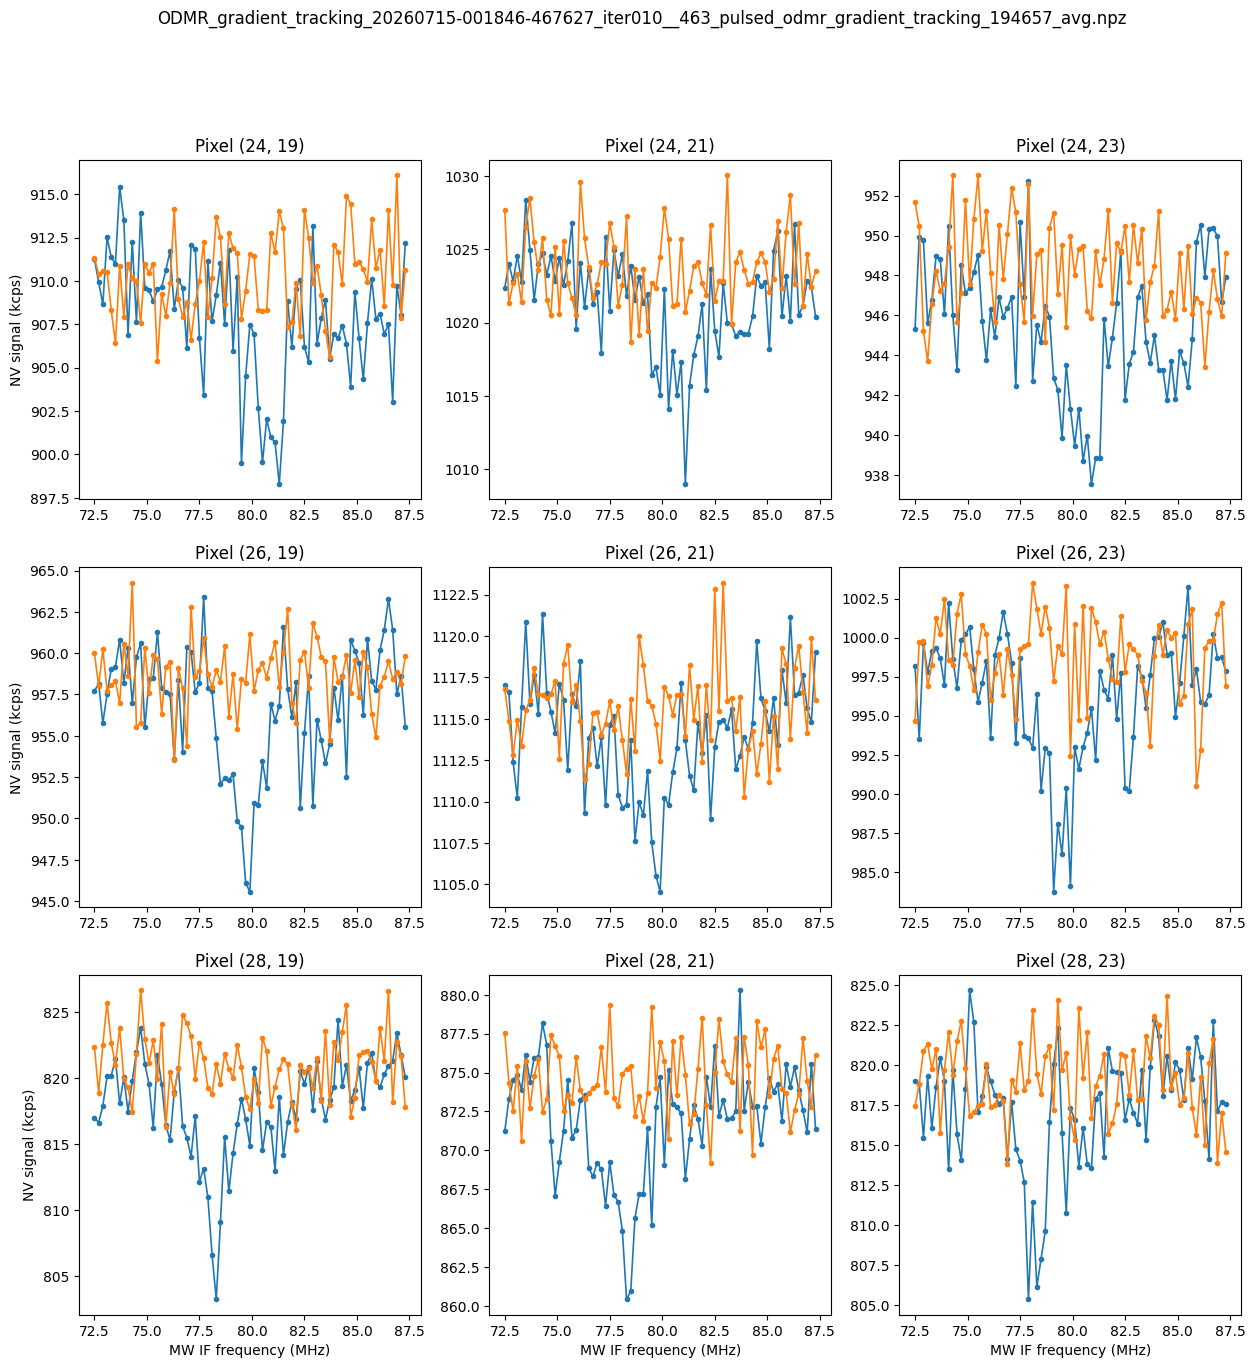

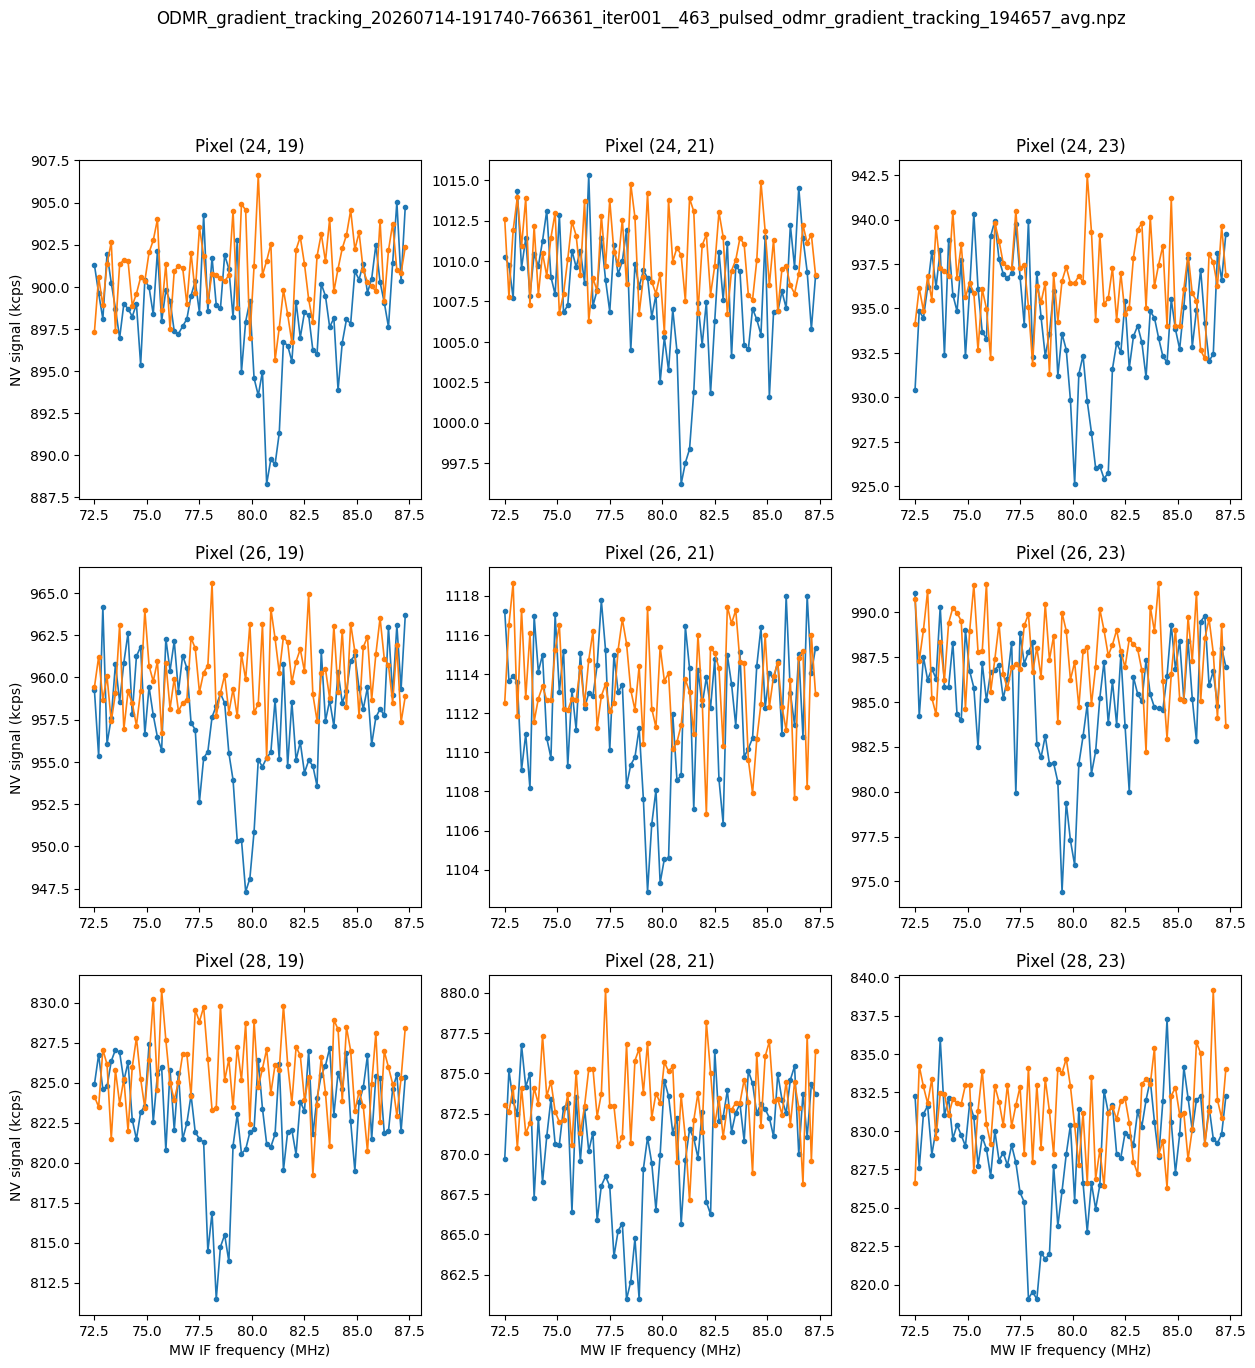

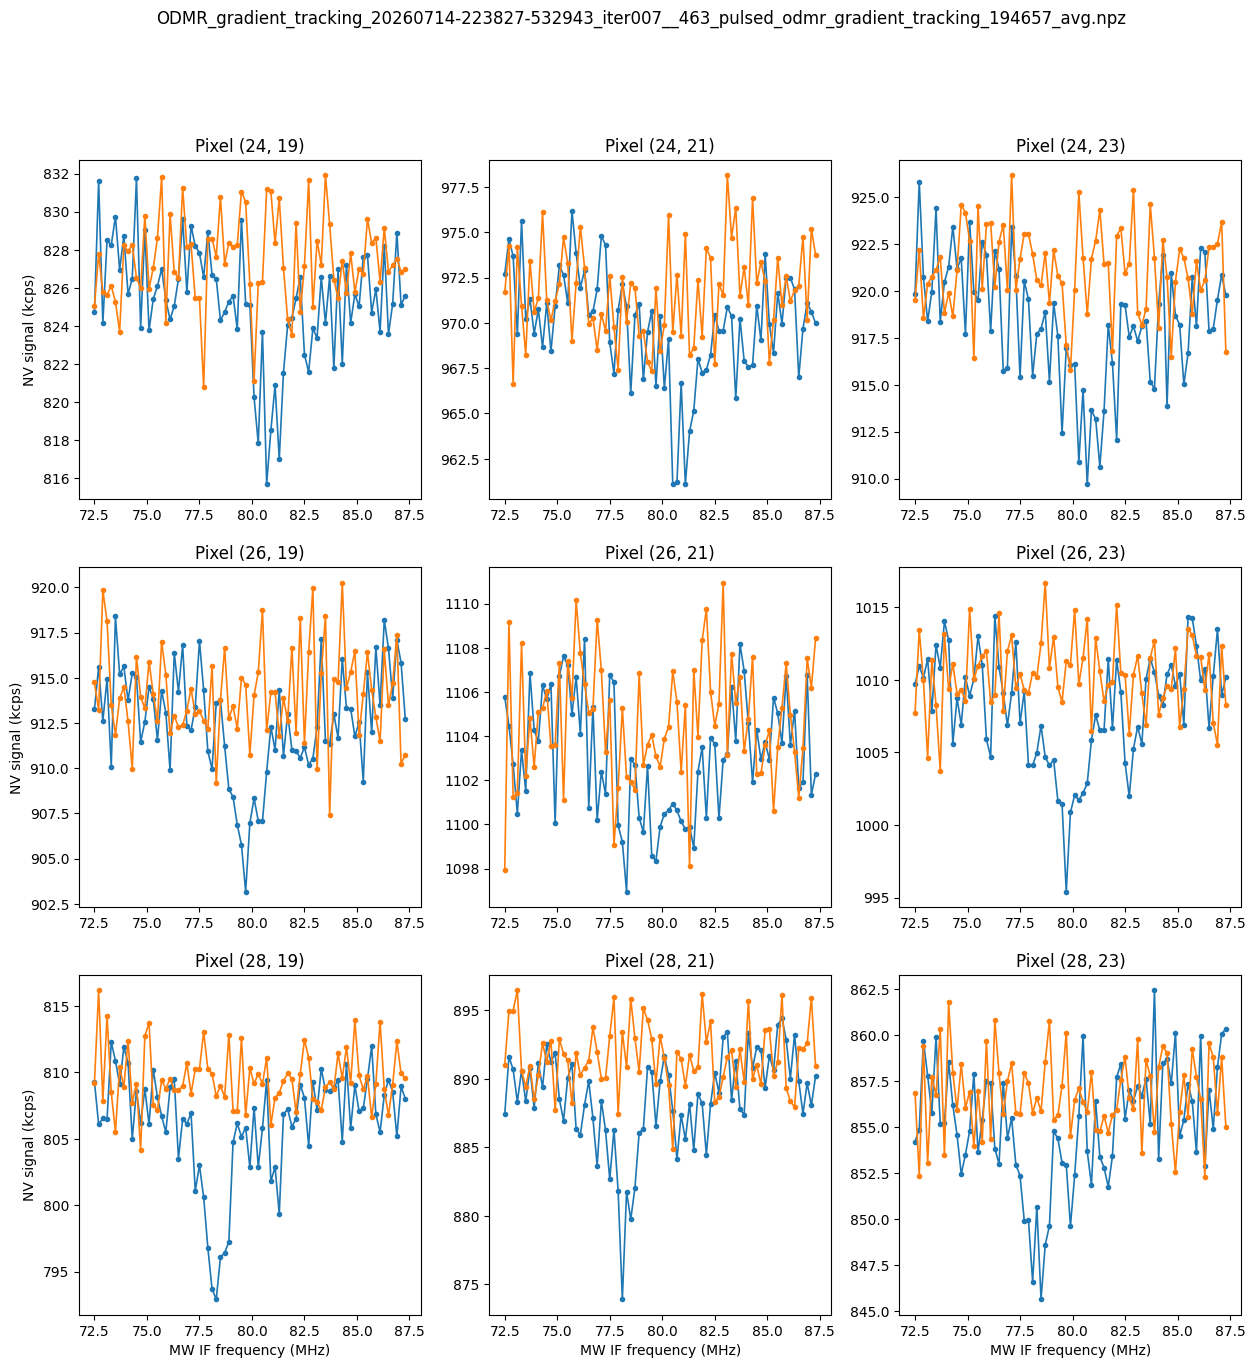

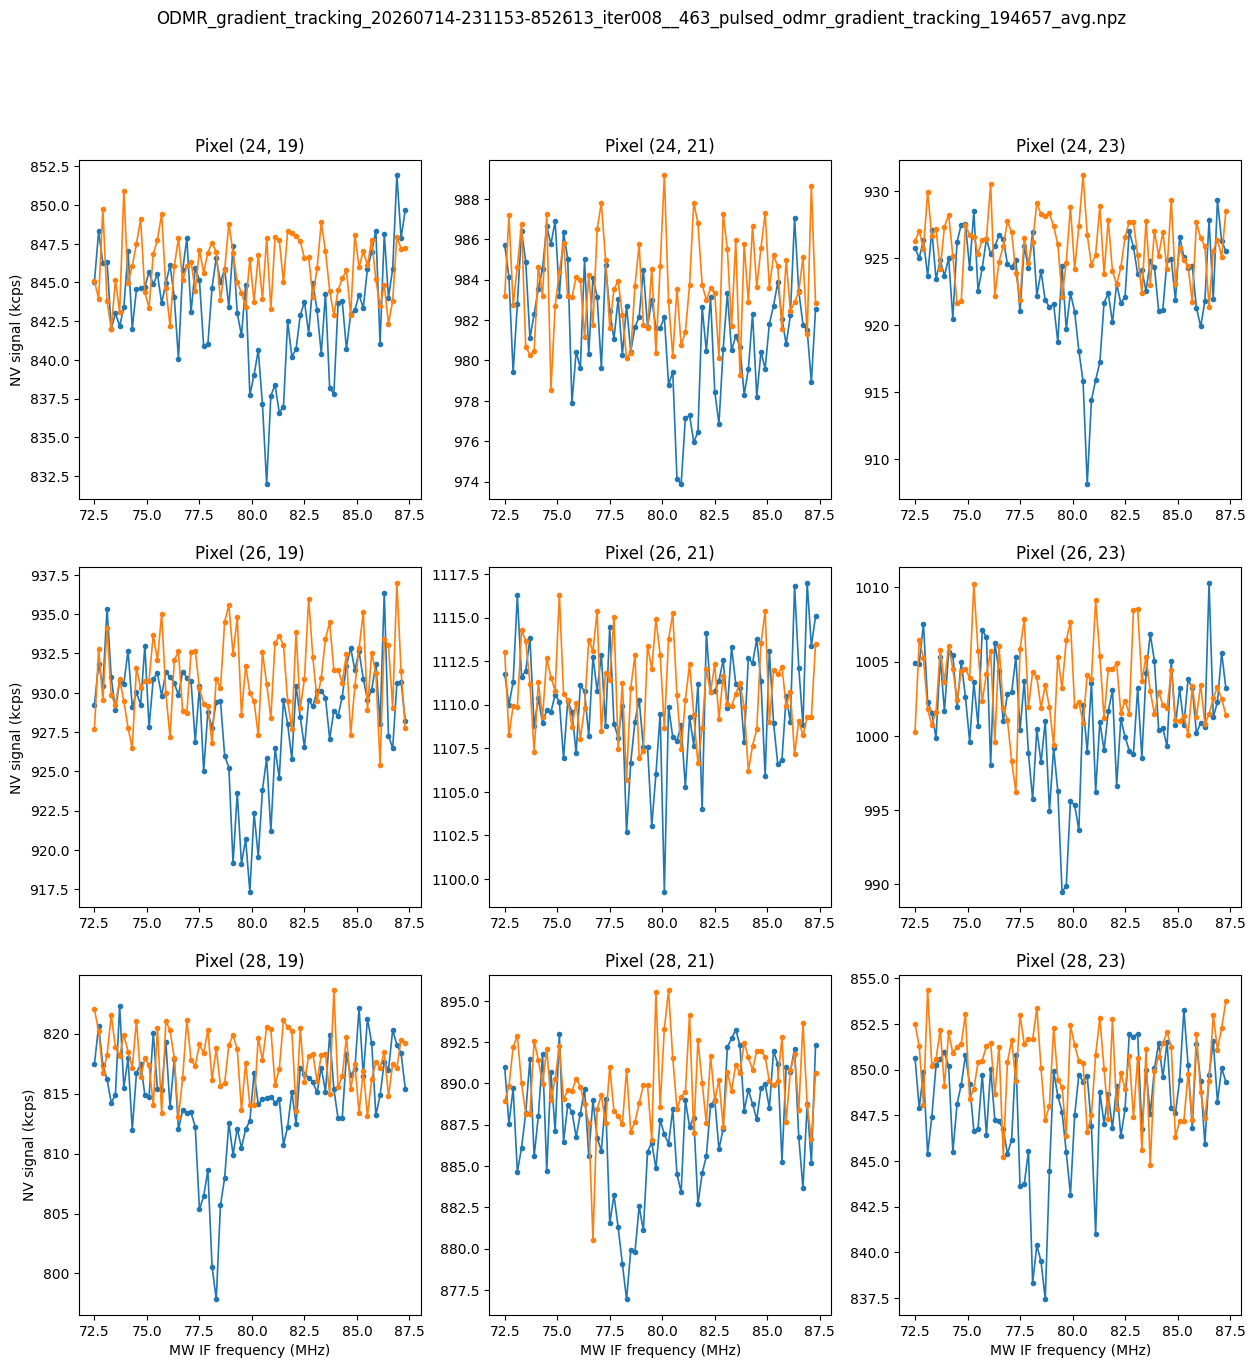

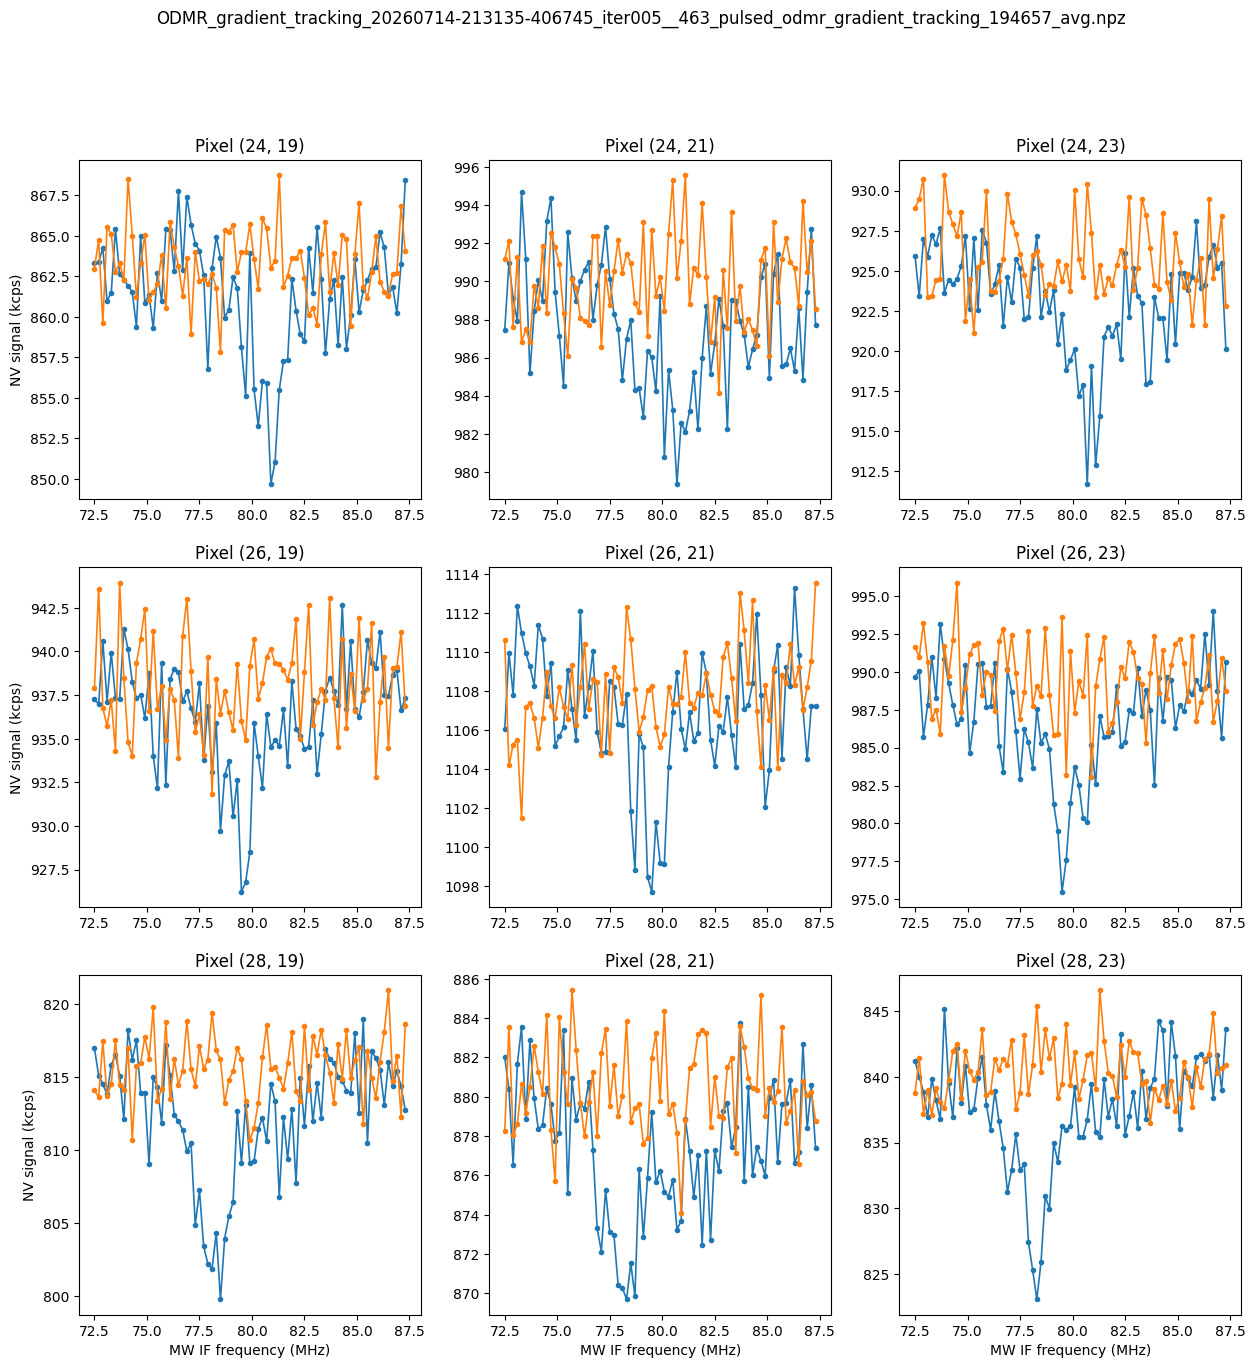

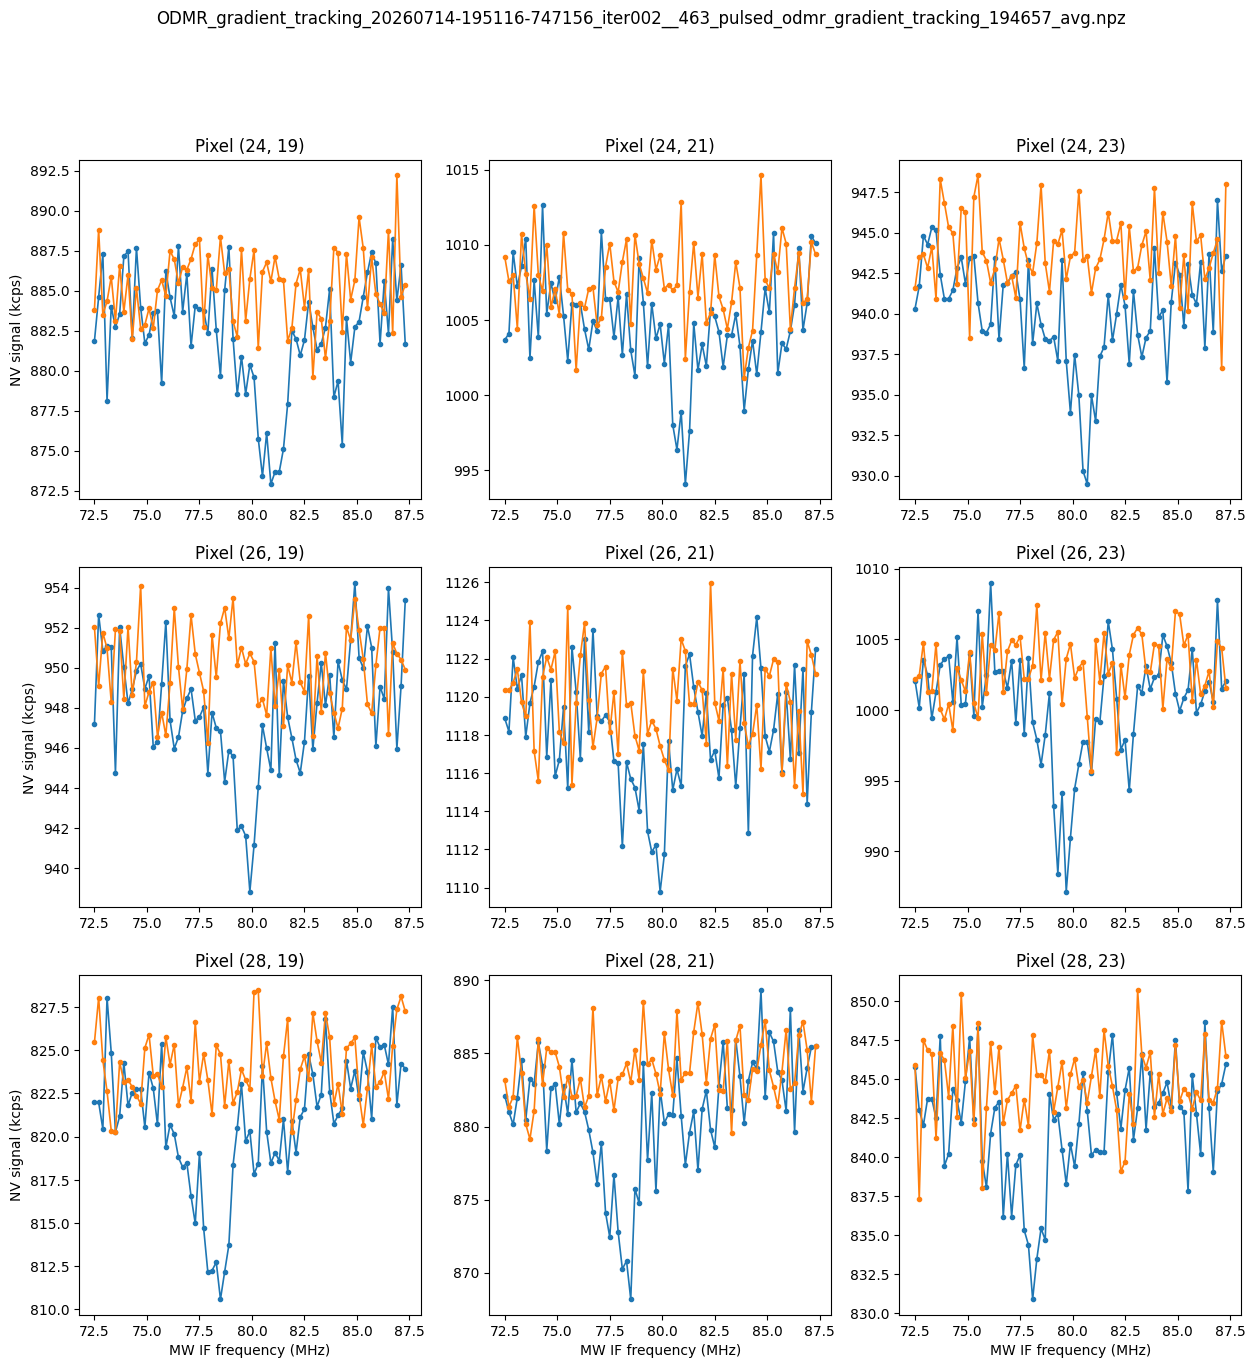

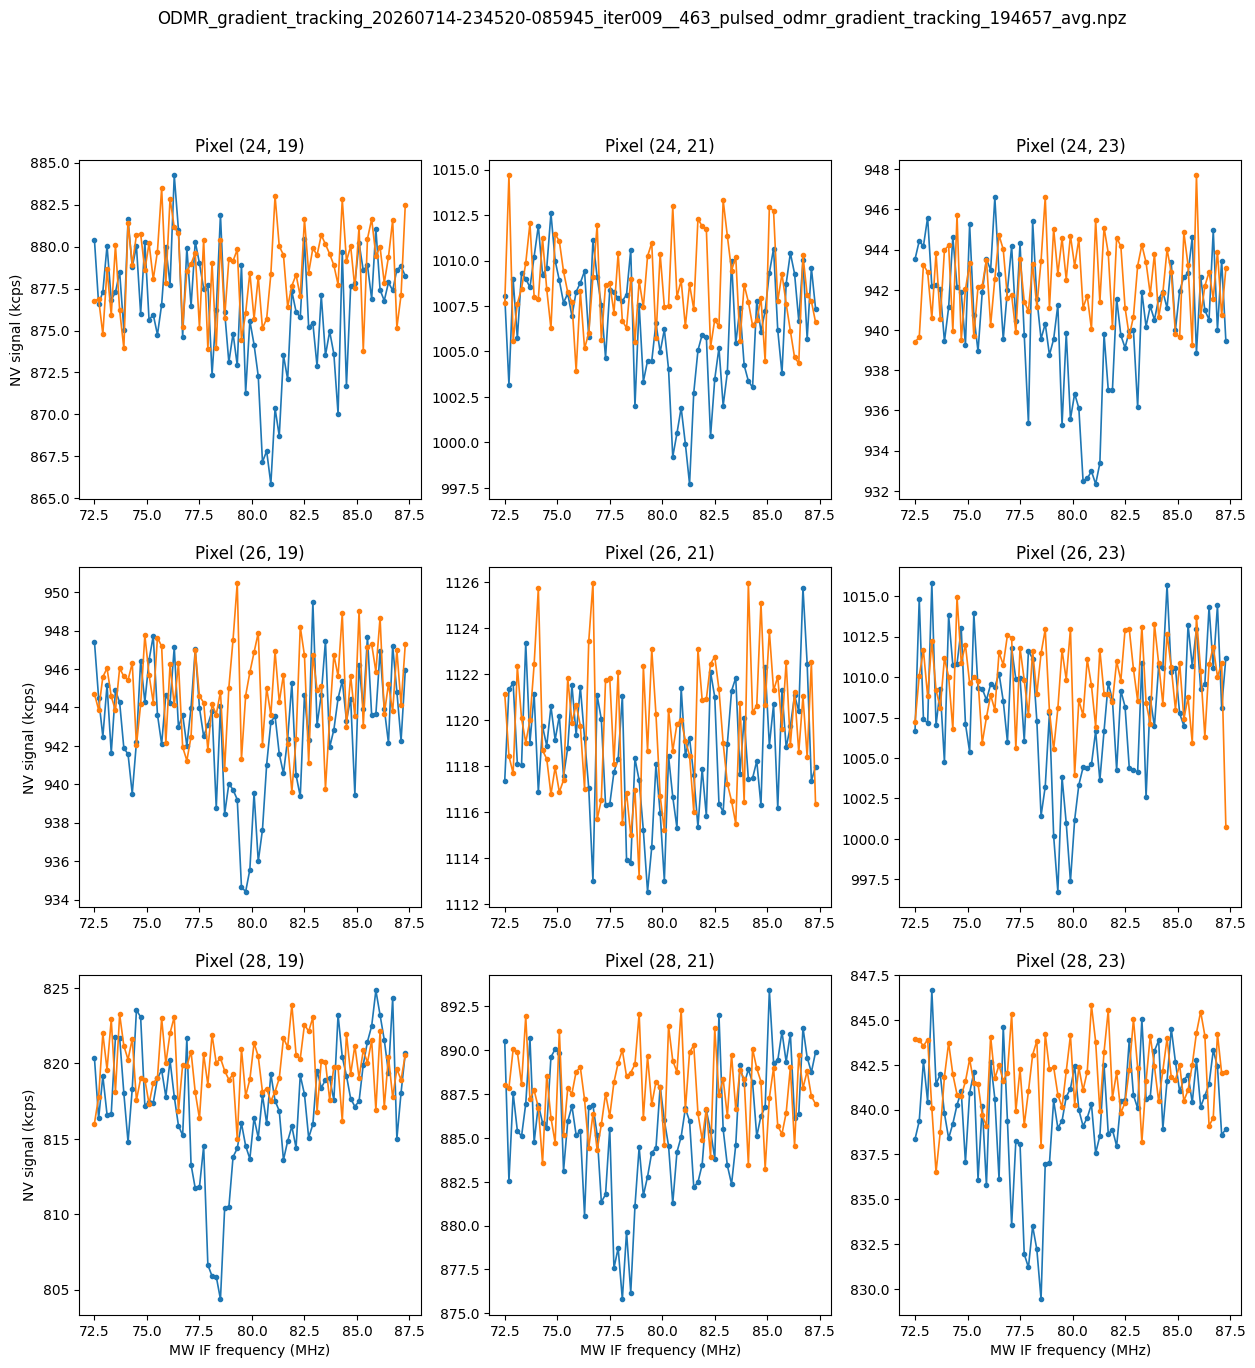

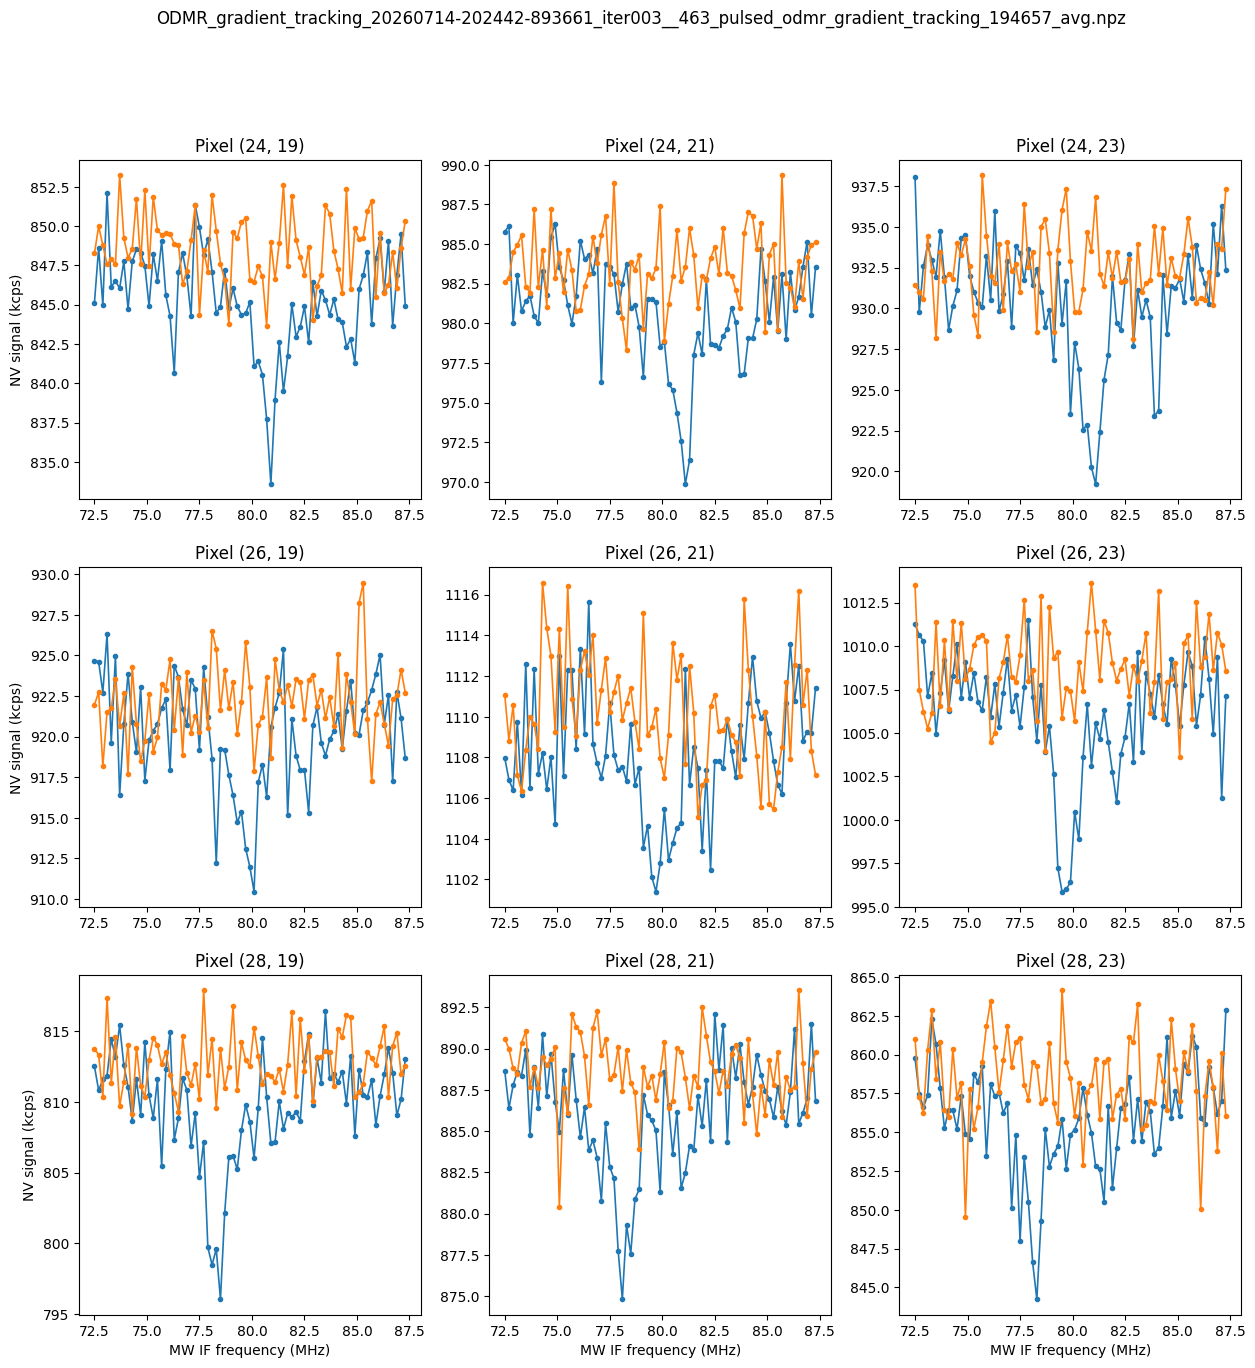

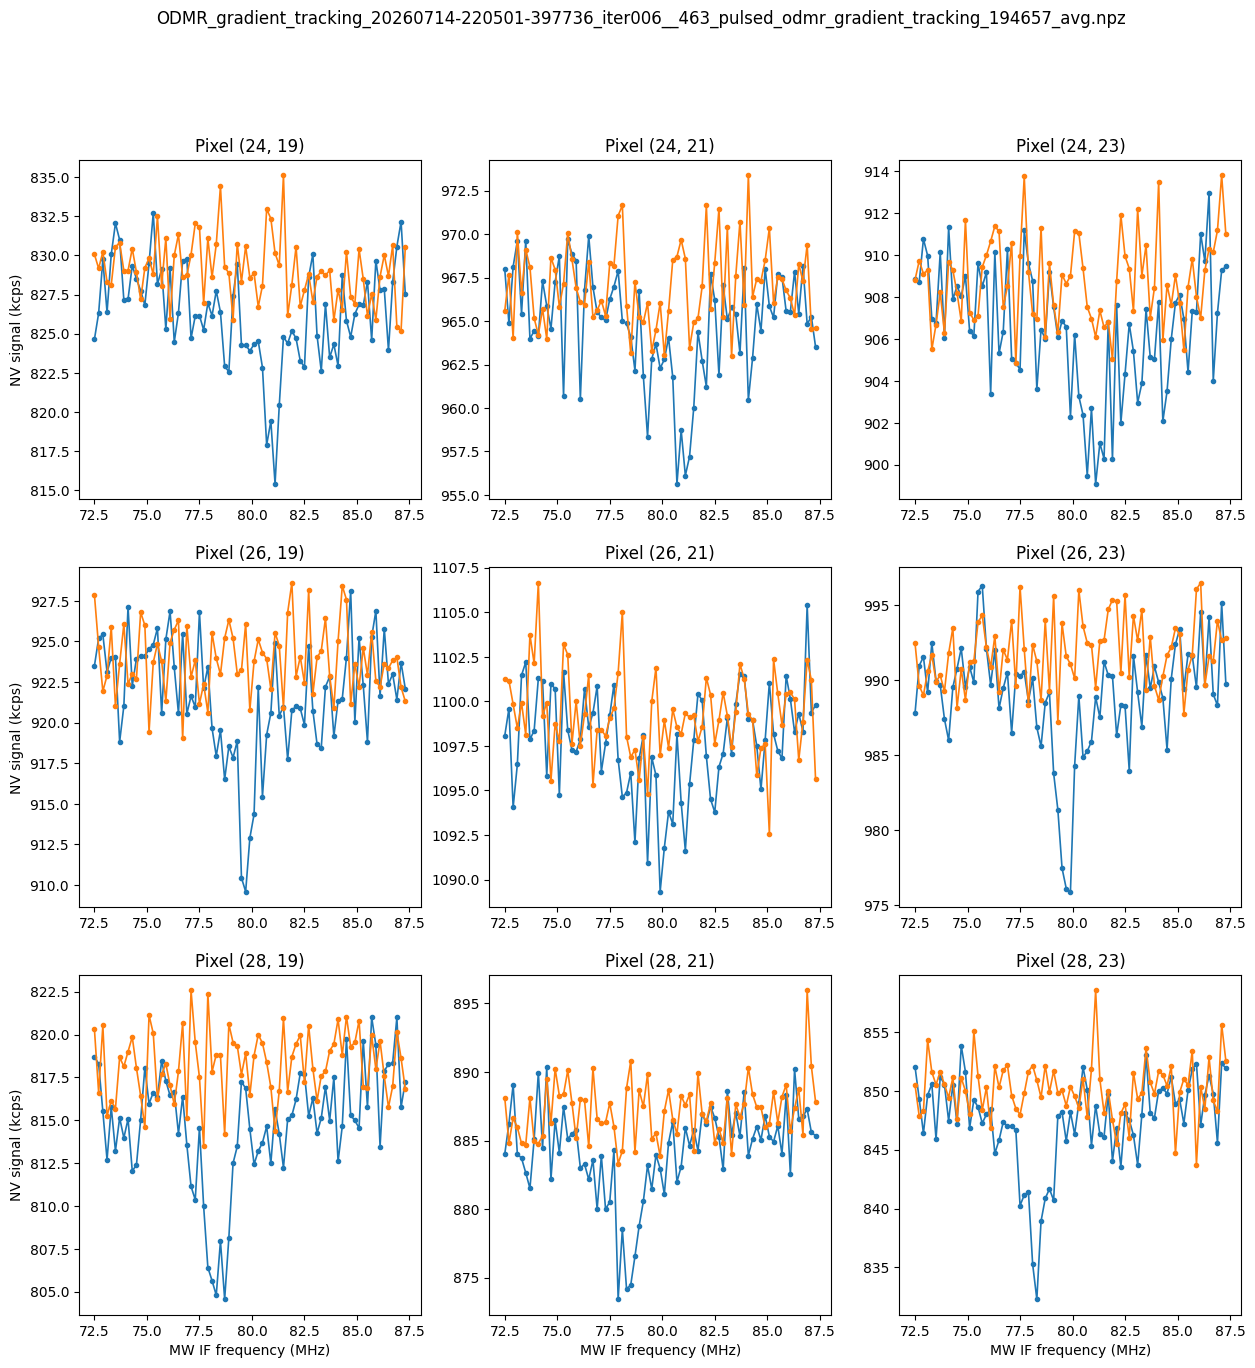

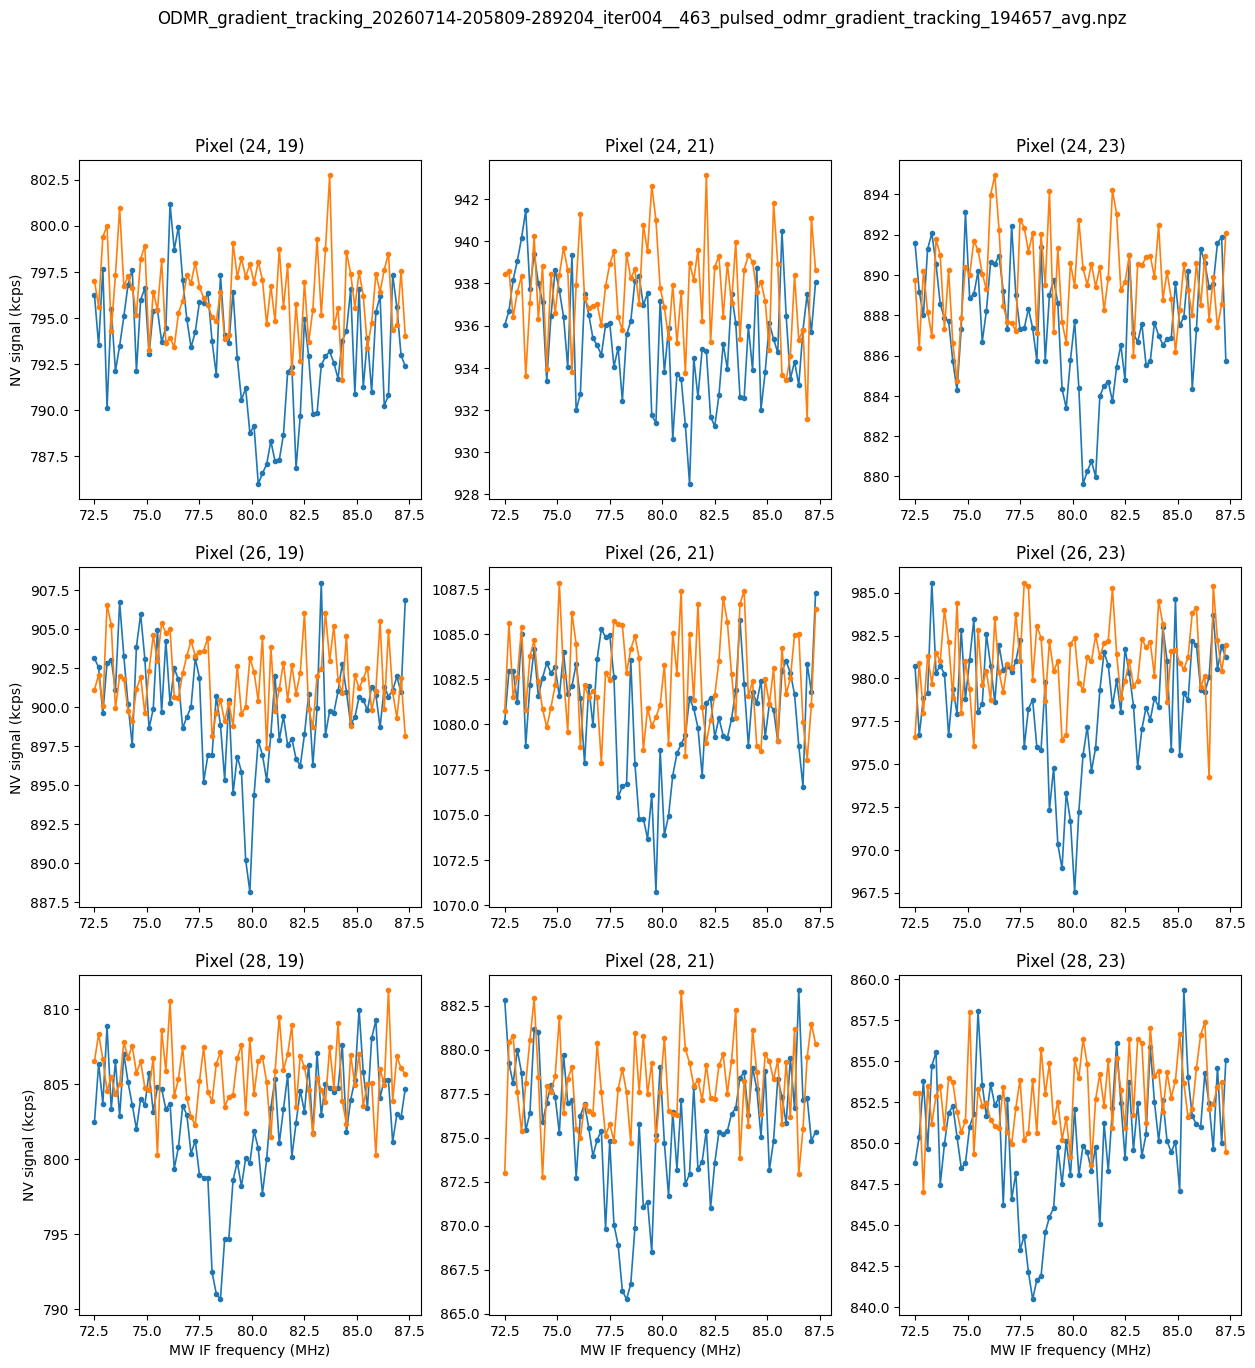

In [40]:
#for each processed file, plot signal and ref for each pixel in 3X3 emitter array centered at brightest pixel
f_mhz = f_vec / 1e6

for k in range(len(spad_processed_files)):

    #find brightest pixel in ref_avg.mean and set as array centre
    ref_frame = ref_avg_cps_bgsub_all[k, :, :, :].mean(axis =0)  # (rows, cols) — mean reference over all frequencies
    bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
    #print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')

    plt.subplots(3, 3, figsize=(15, 15))

    for i in range(3):
        for j in range(3):

            sig_pix = (sig_avg_cps_bgsub_all[k, :, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])
            ref_pix = (ref_avg_cps_bgsub_all[k, :, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])

            plt.suptitle(f'{list(spad_processed_files)[k]}')
            plt.subplot(3, 3, i*3 + j + 1)
            plt.plot(f_mhz, sig_pix/1000, 'o-', ms=3, lw=1.2, label='Signal')
            plt.plot(f_mhz, ref_pix/1000, 'o-', ms=3, lw=1.2, label='Reference')
            plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2})')
            #plt.ylim(0.94,1.02)
            if i==2:
                plt.xlabel('MW IF frequency (MHz)')
            if j==0:
                plt.ylabel('NV signal (kcps)')


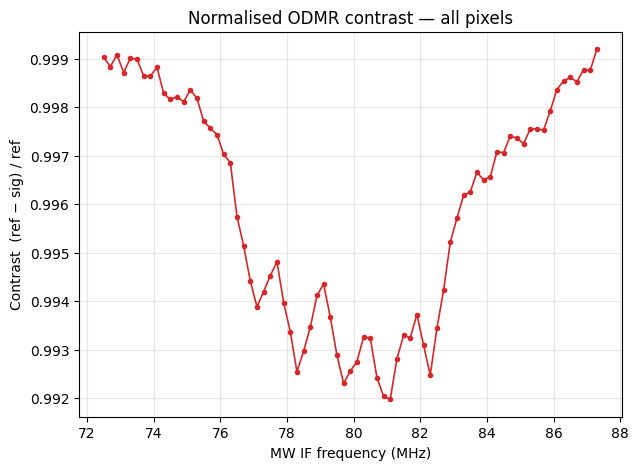

In [41]:
contrast_all = []
#calculate weighted average contrast across all processed files, where weight is number of complete repetitions in each file

for k in range(len(n_complete_reps_all)):
    sig_counts  = sig_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)
    ref_counts  = ref_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)

    with np.errstate(divide='ignore', invalid='ignore'):
        contrast = np.where(ref_counts != 0, 1 - (ref_counts - sig_counts) / ref_counts, 0.0)

    contrast_all.append(contrast)

contrast_all = np.array(contrast_all)
contrast_ave = np.average(contrast_all, axis=0, weights=n_complete_reps_all)

plt.figure(figsize=(7, 5))

plt.plot(f_vec/1e6, contrast_ave, 'o-', ms=3, lw=1.2, color='C3')
plt.xlabel('MW IF frequency (MHz)')
plt.ylabel('Contrast  (ref − sig) / ref')
plt.title('Normalised ODMR contrast — all pixels')
#plt.ylim([0.97, 1.01])
plt.grid(True, alpha=0.3)

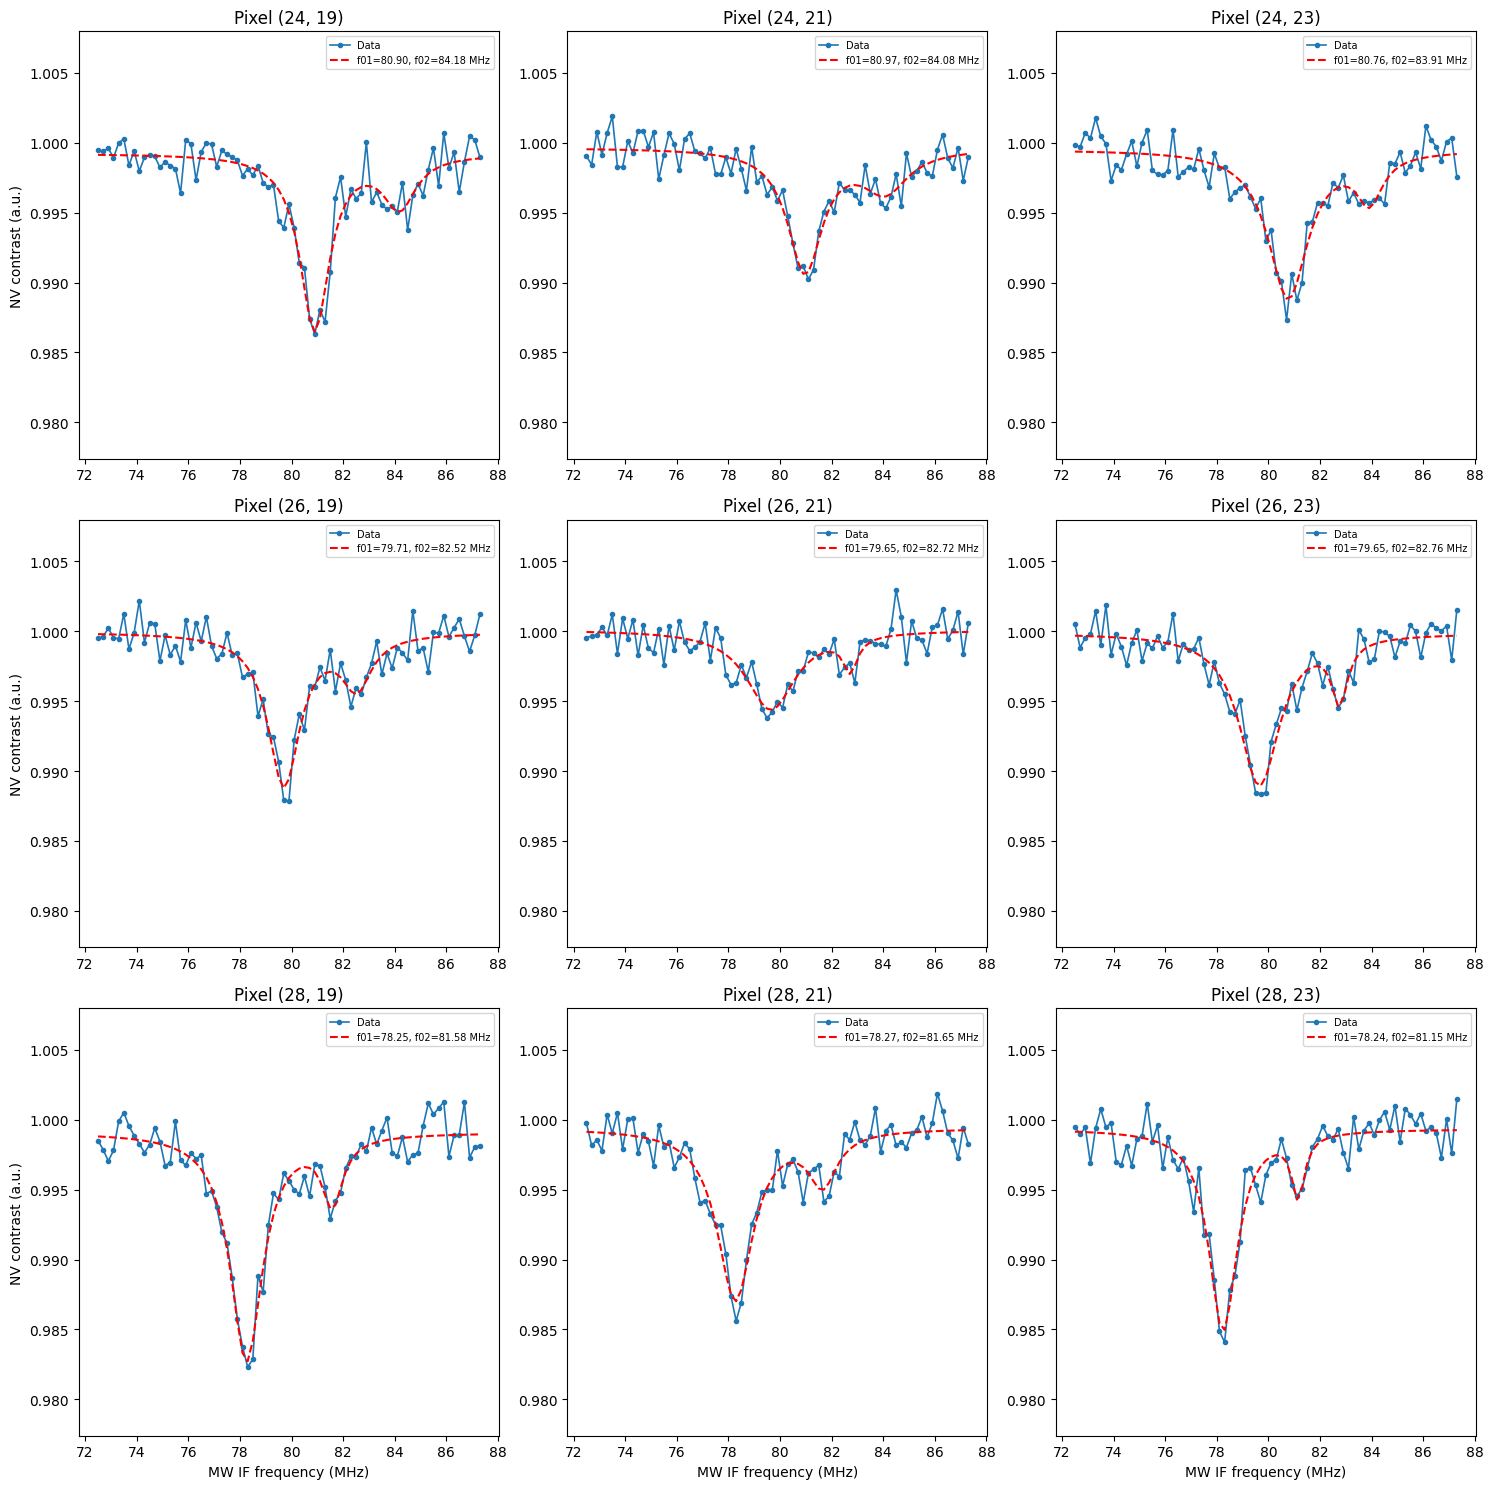


Per-pixel fit results (double Lorentzian):
  Pixel (24,19):  f01=80.8986 MHz  f02=84.1791 MHz  split=3.2805 MHz  amp1=-0.01258  amp2=-0.00366
  Pixel (24,21):  f01=80.9695 MHz  f02=84.0782 MHz  split=3.1087 MHz  amp1=-0.008778  amp2=-0.002925
  Pixel (24,23):  f01=80.7621 MHz  f02=83.9135 MHz  split=3.1514 MHz  amp1=-0.0106  amp2=-0.003313
  Pixel (26,19):  f01=79.7057 MHz  f02=82.5232 MHz  split=2.8175 MHz  amp1=-0.01094  amp2=-0.003704
  Pixel (26,21):  f01=79.6454 MHz  f02=82.7212 MHz  split=3.0758 MHz  amp1=-0.005696  amp2=-0.00244
  Pixel (26,23):  f01=79.6513 MHz  f02=82.7568 MHz  split=3.1055 MHz  amp1=-0.01089  amp2=-0.004383
  Pixel (28,19):  f01=78.2545 MHz  f02=81.5820 MHz  split=3.3275 MHz  amp1=-0.01633  amp2=-0.004715
  Pixel (28,21):  f01=78.2676 MHz  f02=81.6519 MHz  split=3.3842 MHz  amp1=-0.01228  amp2=-0.003731
  Pixel (28,23):  f01=78.2388 MHz  f02=81.1476 MHz  split=2.9089 MHz  amp1=-0.01445  amp2=-0.004421


In [42]:
#plot weighted average contrast signal for 3X3 grid with fixed center pixel

fitter = Fitter()
f_mhz = f_vec / 1e6

# --- pass 1: compute contrasts and fits for all 9 pixels ---
pixel_data = []
for i in range(3):
    for j in range(3):
        sig_norm_pix_all = []
        for k in range(len(n_complete_reps_all)):
            ref_frame = ref_avg_cps_bgsub_all[k, :, :, :].mean(axis=0)
            bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
            sig_pix = sig_avg_cps_bgsub_all[k, :, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2]
            ref_pix = ref_avg_cps_bgsub_all[k, :, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2]
            sig_norm_pix_all.append(1 - ((ref_pix - sig_pix) / ref_pix))

        sig_norm_pix_all = np.array(sig_norm_pix_all)
        sig_norm_pix_avg = np.average(sig_norm_pix_all, axis=0, weights=n_complete_reps_all)
        row, col = bright_rc[0]+2*i-2, bright_rc[1]+2*j-2

        try:
            n_edge = max(1, len(f_mhz) // 10)
            baseline_guess = float(np.median(np.concatenate([sig_norm_pix_avg[:n_edge], sig_norm_pix_avg[-n_edge:]])))
            x01_guess = float(f_mhz[np.argmin(sig_norm_pix_avg)])
            amp_guess = float(np.min(sig_norm_pix_avg)) - baseline_guess
            gamma_guess = float(np.ptp(f_mhz)) / 20.0
            if FIT_MODE == 'double':
                x02_guess = x01_guess + 3.0
                p0 = [x01_guess, gamma_guess, amp_guess, x02_guess, gamma_guess, amp_guess, baseline_guess]
                fit_res = fitter.double_lorentzian(f_mhz, sig_norm_pix_avg, p0=p0)
            else:
                p0 = [x01_guess, gamma_guess, amp_guess, baseline_guess]
                fit_res = fitter.lorentzian(f_mhz, sig_norm_pix_avg, p0=p0)
            y_fit = fit_res.y_fit
            fit_ok = True
        except Exception:
            fit_res = None
            y_fit = None
            fit_ok = False

        pixel_data.append(dict(row=row, col=col, contrast=sig_norm_pix_avg,
                               fit_res=fit_res, y_fit=y_fit, fit_ok=fit_ok))

# shared y limits across all 9 pixels
all_vals = np.concatenate([d['contrast'] for d in pixel_data])
ylo = 0.995 * all_vals.min()
yhi = 1.005 * all_vals.max()

# --- pass 2: plot ---
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fit_results = []

for idx, d in enumerate(pixel_data):
    i, j = idx // 3, idx % 3
    row, col = d['row'], d['col']
    fit_results.append((row, col, d['fit_res']))

    ax = axes[i, j]
    ax.plot(f_mhz, d['contrast'], 'o-', ms=3, lw=1.2, label='Data')
    if d['fit_ok']:
        p = d['fit_res'].params
        if FIT_MODE == 'double':
            label = f"f01={p['x01']:.2f}, f02={p['x02']:.2f} MHz"
        else:
            label = f"f0={p['x0']:.2f} MHz"
        ax.plot(f_mhz, d['y_fit'], 'r--', lw=1.5, label=label)
        ax.legend(fontsize=7)
    ax.set_title(f"Pixel ({row}, {col})")
    ax.set_ylim(ylo, yhi)
    if i == 2:
        ax.set_xlabel('MW IF frequency (MHz)')
    if j == 0:
        ax.set_ylabel('NV contrast (a.u.)')

fig.tight_layout()
plt.show()

print(f"\nPer-pixel fit results ({FIT_MODE} Lorentzian):")
for row, col, fit_res in fit_results:
    if fit_res is not None:
        p = fit_res.params
        if FIT_MODE == 'double':
            print(f"  Pixel ({row:2d},{col:2d}):  "
                  f"f01={p['x01']:.4f} MHz  f02={p['x02']:.4f} MHz  "
                  f"split={p['split']:.4f} MHz  "
                  f"amp1={p['amp1']:.4g}  amp2={p['amp2']:.4g}")
        else:
            print(f"  Pixel ({row:2d},{col:2d}):  "
                  f"f0={p['x0']:.4f} MHz  "
                  f"FWHM={p['fwhm']:.3f} MHz  "
                  f"amp={p['amp']:.4g}")
    else:
        print(f"  Pixel ({row:2d},{col:2d}):  fit failed")

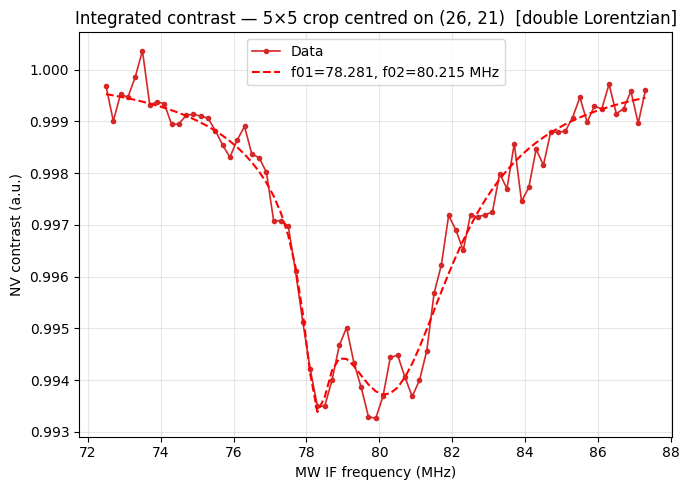

Fit results (5×5 ROI centred on (26, 21)):
  f01:       78.2810 ± 0.0444 MHz
  f02:       80.2149 ± 0.1026 MHz
  split:     1.9338 MHz
  FWHM1:     0.879 MHz
  FWHM2:     4.468 MHz
  amp1:      -0.003098  amp2: -0.006142
  baseline:  1.0000
  Residual RMS: 0.0003746
  SNR (fitted amp/residual RMS): 16.39


In [43]:
# Integrated contrast for 5×5 pixel crop centred on bright_rc

f_mhz = f_vec / 1e6
r0, c0 = bright_rc

contrast_roi_all = []
for k in range(len(n_complete_reps_all)):
    sig_roi = sig_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))  # (F,)
    ref_roi = ref_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))  # (F,)
    with np.errstate(divide='ignore', invalid='ignore'):
        contrast_roi_all.append(np.where(ref_roi != 0, 1 - (ref_roi - sig_roi) / ref_roi, 0.0))

contrast_roi_avg = np.average(contrast_roi_all, axis=0, weights=n_complete_reps_all)

if FIT_MODE == 'double':
    fit_res_roi = Fitter().double_lorentzian(f_mhz, contrast_roi_avg)
else:
    fit_res_roi = Fitter().lorentzian(f_mhz, contrast_roi_avg)

y_fit_roi = fit_res_roi.y_fit
resid_rms_roi = np.sqrt(np.mean((contrast_roi_avg - y_fit_roi) ** 2))
p = fit_res_roi.params

if FIT_MODE == 'double':
    amp_ref = max(abs(p['amp1']), abs(p['amp2']))
    fit_label = f"f01={p['x01']:.3f}, f02={p['x02']:.3f} MHz"
else:
    amp_ref = abs(p['amp'])
    fit_label = f"f0={p['x0']:.3f} MHz"
snr_roi = amp_ref / resid_rms_roi if resid_rms_roi > 0 else np.inf

plt.figure(figsize=(7, 5))
plt.plot(f_mhz, contrast_roi_avg, 'o-', ms=3, lw=1.2, color='C3', label='Data')
plt.plot(f_mhz, y_fit_roi, 'r--', lw=1.5, label=fit_label)
plt.xlabel('MW IF frequency (MHz)')
plt.ylabel('NV contrast (a.u.)')
plt.title(f'Integrated contrast — 5×5 crop centred on ({r0}, {c0})  [{FIT_MODE} Lorentzian]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Fit results (5×5 ROI centred on ({r0}, {c0})):")
if FIT_MODE == 'double':
    print(f"  f01:       {p['x01']:.4f} ± {p['x01_err']:.4f} MHz")
    print(f"  f02:       {p['x02']:.4f} ± {p['x02_err']:.4f} MHz")
    print(f"  split:     {p['split']:.4f} MHz")
    print(f"  FWHM1:     {p['fwhm1']:.3f} MHz")
    print(f"  FWHM2:     {p['fwhm2']:.3f} MHz")
    print(f"  amp1:      {p['amp1']:.4g}  amp2: {p['amp2']:.4g}")
    print(f"  baseline:  {p['baseline']:.4f}")
else:
    print(f"  f0:        {p['x0']:.4f} ± {p['x0_err']:.4f} MHz")
    print(f"  FWHM:      {p['fwhm']:.3f} ± {p['fwhm_err']:.3f} MHz")
    print(f"  amplitude: {p['amp']:.4g}")
    print(f"  baseline:  {p['baseline']:.4f}")
print(f"  Residual RMS: {resid_rms_roi:.4g}")
print(f"  SNR (fitted amp/residual RMS): {snr_roi:.2f}")

In [44]:
#Integrated contrast for 5×5 pixel crop centred on bright_rc
#evaluate noise from mean reference (only works for single file)

f_mhz = f_vec / 1e6
r0, c0 = bright_rc

contrast_roi_all = []
std_all = []
mean_all = []
k = len(n_complete_reps_all)-1 #use last file (should be only one) to evaluate noise from mean reference
sig_roi = sig_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))  # (F,)
ref_roi = ref_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))  # (F,)
with np.errstate(divide='ignore', invalid='ignore'):
    contrast_roi_all.append(np.where(ref_roi != 0, 1 - (ref_roi - sig_roi) / ref_roi, 0.0))
mean_all.append(np.mean(ref_roi))
std_all.append(np.std(ref_roi))

contrast_roi_avg = np.average(contrast_roi_all, axis=0)
std_roi_avg = np.average(std_all, axis=0)
mean_roi_avg = np.average(mean_all, axis=0)

if FIT_MODE == 'double':
    fit_res_roi = Fitter().double_lorentzian(f_mhz, contrast_roi_avg)
    amp_ref = max(abs(fit_res_roi.params['amp1']), abs(fit_res_roi.params['amp2']))
else:
    fit_res_roi = Fitter().lorentzian(f_mhz, contrast_roi_avg)
    amp_ref = abs(fit_res_roi.params['amp'])

noise = std_roi_avg
amp_cps = amp_ref * mean_roi_avg
snr_roi = np.abs(amp_cps) / noise if noise > 0 else np.inf

print(f"  amplitude [cps]: {amp_cps:.4g}")
print(f"  Noise (std of ref counts): {noise:.4g}")
print(f"  SNR (using reference measurement): {snr_roi:.2f}")

  amplitude [cps]: 1.196e+05
  Noise (std of ref counts): 1.16e+04
  SNR (using reference measurement): 10.31
